# Figures and Statistics for Thermal Landscapes Project
 PB 12/12/22 updated by EH on 6/25/2026

Reads in pickle object files made with RectifiedImageProcessing scripts, and makes plots for the Thermal Landscapes paper.

###IMPORTANT NOTE###
RUN AFTER Figures_Stats_UplandLowlandSites

In [1]:
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle

mast_path = '/n/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes'

# Comparative figure outputs
figdir = Path(f'{mast_path}/src/3_process_figs_stats/figs/Final_6252026_WeatherUpdate/')
figdir.mkdir(parents=True, exist_ok=True)

# Comparative stats outputs
statsdir = Path(f'{mast_path}/src/3_process_figs_stats/stats/')
statsdir.mkdir(parents=True, exist_ok=True)

# Pixel pickle inputs from the site-processing notebooks
pickledir = Path(f'{mast_path}/out/pixelpickles')
# Random Number Seed
# Set a random number seed so that the analysis is reproducible 1/16/23
# https://stats.stackexchange.com/questions/354373/what-exactly-is-a-seed-in-a-random-number-generator
seed = 42

# # # END USER INPUTS

In [2]:
# Open up pickles and save in dictionaries
pix_dict = {}

for p in pickledir.glob('*.obj'):
    df = pd.read_pickle(p)
    projstr = p.name.split('_pixels.obj')[0]
    pix_dict[projstr] = df.copy(deep=True)

print("Loaded sites:")
print(pix_dict.keys())

if 'Nkuhlu' in pix_dict:
    pix_dict['Nkuhlu']['Exclosure'] = pix_dict['Nkuhlu']['Exclosure'].replace({
        'Full': 'Inside',
        'Open': 'Outside'
    })

Loaded sites:
dict_keys(['Letaba', 'Makhohlola', 'BuffaloCamp', 'Nkuhlu', 'RoanCamp', 'Hlangwine'])


In [3]:
# Define Settings for Plotting

# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.3, style="ticks", rc=custom_params)

# Set hue order for plotting
exclosure_hues=["Outside", "Inside"]
topo_hues = ["Upland", "Lowland"]

# List out Sites in Order (top to bottom) for plotting
sites = ['Letaba', 'Nkuhlu', 'Hlangwine', 'RoanCamp', 'BuffaloCamp', 'Makhohlola']

In [4]:
# Define functions for stats and effect size calculation
# Added more stats 1/26/23
from scipy.stats import ttest_ind
import numpy as np

def EffectSize_by_Exclosure(df, var='Temperature', seed=None):

    # set random number seed
    if not seed:
        seed = 42
        
    # Split by Inside and Outside
    df_in = df.loc[df.Exclosure=='Inside']
    df_out = df.loc[df.Exclosure=='Outside']
    
    # Get sample size (number of pixels)
    n_in = len(df_in[var])
    n_out = len(df_out[var])
    
    # Find the smaller area
    # and set the number of pixels to sample 
    # to be ~66% of the number of pixels in the smallest area
    numpix = int(np.floor(0.66*np.min([n_in, n_out])))
            
    # Sample pixels to account for spatial autocorrelation
    # Added a random number seed here so that results are reproducible 1/16
    df_in = df_in.sample(n=numpix, random_state=seed)
    df_out = df_out.sample(n=numpix, random_state=seed)
    
    # Run a welch's t-test (equal variances not assumed)
    t, p = ttest_ind(df_in[var],
                     df_out[var],
                     equal_var=False)
    
    # Also, run Cohen's D as a measure of effect size per image
    cd = cohen_d(df_in[var],
                 df_out[var])
    
    # Get sample size (number of pixels), and means
    n_in_final = len(df_in[var])
    n_out_final = len(df_out[var])
    
    mean_in = df_in[var].mean()
    mean_out = df_out[var].mean()
    meandiff = mean_in-mean_out
    
    std_in = df_in[var].std()
    std_out = df_out[var].std()
    stddiff = df_in[var].std() - df_out[var].std()
    
    CV_in =  df_in[var].std() / df_in[var].mean()
    CV_out = df_out[var].std() / df_out[var].mean()
    CVdiff = (df_in[var].std() / df_in[var].mean()) - (df_out[var].std() / df_out[var].mean())
    
    # Compile results
    results = (t, p, cd,
               meandiff, mean_in, mean_out,
               n_in_final, n_out_final,
               stddiff, std_in, std_out,
               CVdiff, CV_in, CV_out)
    
    return results

# Cohen's D - A Measure of effect size 
# aka: a measure of standardized mean difference
# mean1 - mean2 / pooled sample Std
# https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python/33002123#33002123
# Other useful links:
# http://ethen8181.github.io/machine-learning/ab_tests/causal_inference/matching.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
# https://en.wikipedia.org/wiki/Effect_size#Difference_family:_Effect_sizes_based_on_differences_between_means
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)


In [6]:
# Loop through and calculate statistics, grouped by different variables (img, topo, and exclosure)
# Note that you sample 66% of the exlosure with the smallest number of pixels (inside or outside) 
# Each time you run it, it will resample those randomly (so it's not reproducable).

# initialize list for temperature ttest and effect size to make allsites file
df_ES_list_temp = []
df_ES_list_pai = []
df_ES_list_height = []

for s in sites:
    if 'Temperature_eVeg' not in pix_dict[s].columns and 'Temperature' in pix_dict[s].columns:
        pix_dict[s]['Temperature_eVeg'] = pix_dict[s]['Temperature']
        
for s in sites:
    
    # Get all pixels included in the current site
    df_pixels = pix_dict[s]
    
    # # # 1)  Make output summary stat files
    statsbyEx = df_pixels.groupby(['Exclosure']).describe()
    
    statsbyEx.to_csv(statsdir / f'Stats_byExclosure_{s}.csv')
    
    statsbyExbyImg = df_pixels.groupby(['imgf', 'Exclosure']).describe()
    
    statsbyExbyImg.to_csv(statsdir / f'Stats_byExclosure_byImage_{s}.csv')
    
    if 'Topo' in df_pixels.columns:
    
        statsbyExbyTopo = df_pixels.groupby(['Topo', 'Exclosure']).describe()
        
        statsbyExbyTopo.to_csv(statsdir / f'Stats_byExclosure_byTopoPosition_{s}.csv')
        
        statsbyExbyImgbyTopo = df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).describe()
        
        statsbyExbyImgbyTopo.to_csv(statsdir / f'Stats_byExclosure_byTopoPosition_byImage_{s}.csv')
        
    # # # 2) Make effect size and ttest statistic files by image and summarized for each site
    statsbyImg = df_pixels.groupby(['imgf'])
    
    # # Ttest and cohens d for temperature
    ES_results = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_eVeg', seed=seed))
    
    df_list = []
    
    for i in ES_results.items():
        
        df = pd.DataFrame({'site':s,
                             'imgf': [i[0]],
                             'tstat':[i[1][0]],
                             'p':[i[1][1]],
                             'cohensd':[i[1][2]],
                             'meandiff':[i[1][3]],
                             'mean_inside':[i[1][4]],
                             'mean_outside':[i[1][5]],
                             'n_inside':[i[1][6]],
                             'n_outside':[i[1][7]],
                             'stddiff':[i[1][8]],
                             'std_inside':[i[1][9]],
                             'std_outside':[i[1][10]],
                             'CVdiff':[i[1][11]],
                             'CV_inside':[i[1][12]],
                             'CV_outside':[i[1][13]]})

        df_list.append(df)
    
    # Compile temperature statistics for this site
    # and save
    ESstats_s = pd.concat(df_list, ignore_index=True)
    ESstats_s.to_csv(statsdir / f'TTestandEffectSizeStats_Temperature_byExclosure_byImage_{s}.csv')
    df_ES_list_temp.append(ESstats_s)
    
    # # Ttest and cohens d for Height
    ES_Height_results = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Height', seed=seed))
    
    df_height_list = []
    
    for i in ES_Height_results.items():

        df = pd.DataFrame({'site':s,
                             'imgf': [i[0]],
                             'tstat':[i[1][0]],
                             'p':[i[1][1]],
                             'cohensd':[i[1][2]],
                             'meandiff':[i[1][3]],
                             'mean_inside':[i[1][4]],
                             'mean_outside':[i[1][5]],
                             'n_inside':[i[1][6]],
                             'n_outside':[i[1][7]],
                             'stddiff':[i[1][8]],
                             'std_inside':[i[1][9]],
                             'std_outside':[i[1][10]],
                             'CVdiff':[i[1][11]],
                             'CV_inside':[i[1][12]],
                             'CV_outside':[i[1][13]]})

        df_height_list.append(df)
    
    # Compile temperature statistics for this site
    # and save
    ESstats_height_s = pd.concat(df_height_list, ignore_index=True)
    ESstats_height_s.to_csv(statsdir / f'TTestandEffectSizeStats_Height_byExclosure_byImage_{s}.csv')
    df_ES_list_height.append(ESstats_height_s)
    
    # # Ttest and cohens d for PAI
    ES_PAI_results = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='PAI', seed=seed))
    
    df_PAI_list = []
    
    for i in ES_PAI_results.items():

        df = pd.DataFrame({'site':s,
                             'imgf': [i[0]],
                             'tstat':[i[1][0]],
                             'p':[i[1][1]],
                             'cohensd':[i[1][2]],
                             'meandiff':[i[1][3]],
                             'mean_inside':[i[1][4]],
                             'mean_outside':[i[1][5]],
                             'n_inside':[i[1][6]],
                             'n_outside':[i[1][7]],
                             'stddiff':[i[1][8]],
                             'std_inside':[i[1][9]],
                             'std_outside':[i[1][10]],
                             'CVdiff':[i[1][11]],
                             'CV_inside':[i[1][12]],
                             'CV_outside':[i[1][13]]})

        df_PAI_list.append(df)
    
    # Compile PAI statistics for this site
    # and save
    ESstats_PAI_s = pd.concat(df_PAI_list, ignore_index=True)
    ESstats_PAI_s.to_csv(statsdir / f'TTestandEffectSizeStats_PAI_byExclosure_byImage_{s}.csv')
    df_ES_list_pai.append(ESstats_PAI_s)

In [7]:
pix_dict['RoanCamp'].keys()

Index(['Temperature', 'Height', 'Elevation', 'Exclosure', 'Topo', 'imgf',
       'CanopyDensity', 'PAI', 'VegType', 'CanopyDensityPercent',
       'Temperature_eVeg'],
      dtype='object')

In [8]:
# Path('./stats/TestandEffectSizeStats_Temperature_byExclosure_byImage_AllSites.csv').absolute()

In [9]:
# Compile ES temperature statistics from all sites
ESstats_allsites = pd.concat(df_ES_list_temp, ignore_index=True)

# save them 
ESstats_allsites.to_csv(statsdir / 'TTestandEffectSizeStats_Temperature_byExclosure_byImage_AllSites.csv')

# Group by site for below calculations
ESstats_bysite = ESstats_allsites.groupby(['site'])

# Redone 1/26 - export stats of all vars at once
for c in ['tstat', 'p', 'cohensd', 'meandiff', 'mean_inside',
       'mean_outside', 'n_inside', 'n_outside', 'stddiff', 'std_inside',
       'std_outside', 'CVdiff', 'CV_inside', 'CV_outside']:
    
    ESstats_bysite[c].describe().to_csv(statsdir / f'{c}_Temperature_Summary_AllSites.csv')

# # Also, save cohens d, summarized
# cd_summary = ESstats_bysite.cohensd.describe()
# cd_summary.to_csv(f'./stats/CohensD_Temperature_Summary_AllSites.csv')

# # Also, save mean diff in temp, summarized
# md_summary = ESstats_bysite.meandiff.describe()
# md_summary.to_csv(f'./stats/MeanDiff_Temperature_Summary_AllSites.csv')

# # Also, save other stats
# CVdiff_summary = ESstats_bysite.CVdiff.describe()
# CVdiff_summary.to_csv(f'./stats/CVDiff_Temperature_Summary_AllSites.csv')

# Also, calc the number and proportion of images with significant p-values and mean diff < 0
# Aka - proporation of images with significant differences that showed inside being cooler than outside
def calcpropimages(ES):
    trues = [((es.p <= 0.001) & (es.meandiff < 0)) for es in ES.itertuples()]
    ntrues = np.sum(trues)
    prop = ntrues / len(trues)
    return prop

propimg_summary = ESstats_bysite.apply(lambda x: calcpropimages(x))
propimg_summary.to_csv(statsdir / 'PropImageswithSigDiffinTemperature_AllSites.csv')

In [10]:
# Compile ES Height statistics from all sites
ESstats_height_allsites = pd.concat(df_ES_list_height, ignore_index=True)

# save them 
ESstats_height_allsites.to_csv(f'./stats/TTestandEffectSizeStats_Height_byExclosure_byImage_AllSites.csv')

# Group by site for below calculations
ESstats_height_bysite = ESstats_height_allsites.groupby(['site'])


# Redone 1/26 - export stats of all vars at once
for c in ['tstat', 'p', 'cohensd', 'meandiff', 'mean_inside',
       'mean_outside', 'n_inside', 'n_outside', 'stddiff', 'std_inside',
       'std_outside', 'CVdiff', 'CV_inside', 'CV_outside']:
    
    ESstats_height_bysite[c].describe().to_csv(f'./stats/{c}_Height_Summary_AllSites.csv')

# # Also, save cohens d, summarized
# cd_summary_height = ESstats_height_bysite.cohensd.describe()
# cd_summary_height.to_csv(f'./stats/CohensD_Height_Summary_AllSites.csv')

# # Also, save mean diff in temp, summarized
# md_summary_height = ESstats_height_bysite.meandiff.describe()
# md_summary_height.to_csv(f'./stats/MeanDiff_Height_Summary_AllSites.csv')

# # Also, save other stats
# CVdiff_summary_h = ESstats_height_bysite.CVdiff.describe()
# CVdiff_summary_h.to_csv(f'./stats/CVDiff_Height_Summary_AllSites.csv')

# Also, calc the number and proportion of images with significant p-values and mean diff < 0
# Aka - proporation of images with significant differences that showed inside being TALLER than Outside
def calcpropimages_height(ES):
    trues = [((es.p <= 0.001) & (es.meandiff > 0)) for es in ES.itertuples()]
    ntrues = np.sum(trues)
    prop = ntrues / len(trues)
    return prop

propimg_summary_height = ESstats_height_bysite.apply(lambda x: calcpropimages_height(x))
propimg_summary_height.to_csv(f'./stats/PropImageswithSigDiffinHeight_AllSites.csv')


In [11]:
# Compile ES PAI statistics from all sites
ESstats_PAI_allsites = pd.concat(df_ES_list_pai, ignore_index=True)

# save them 
ESstats_PAI_allsites.to_csv(f'./stats/TTestandEffectSizeStats_PAI_byExclosure_byImage_AllSites.csv')

# Group by site for below calculations
ESstats_PAI_bysite = ESstats_PAI_allsites.groupby(['site'])

# Redone 1/26 - export stats of all vars at once
for c in ['tstat', 'p', 'cohensd', 'meandiff', 'mean_inside',
       'mean_outside', 'n_inside', 'n_outside', 'stddiff', 'std_inside',
       'std_outside', 'CVdiff', 'CV_inside', 'CV_outside']:
    
    ESstats_PAI_bysite[c].describe().to_csv(f'./stats/{c}_PAI_Summary_AllSites.csv')

# # Also, save cohens d, summarized
# cd_summary_PAI = ESstats_PAI_bysite.cohensd.describe()
# cd_summary_PAI.to_csv(f'./stats/CohensD_PAI_Summary_AllSites.csv')

# # Also, save mean diff in temp, summarized
# md_summary_PAI = ESstats_PAI_bysite.meandiff.describe()
# md_summary_PAI.to_csv(f'./stats/MeanDiff_PAI_Summary_AllSites.csv')

# # Also, save other stats
# CVdiff_summary_h = ESstats_PAI_bysite.CVdiff.describe()
# CVdiff_summary_h.to_csv(f'./stats/CVDiff_Height_Summary_AllSites.csv')

# Also, calc the number and proportion of images with significant p-values and mean diff < 0
# Aka - proporation of images with significant differences that showed inside being TALLER than Outside
def calcpropimages_PAI(ES):
    trues = [((es.p <= 0.001) & (es.meandiff > 0)) for es in ES.itertuples()]
    ntrues = np.sum(trues)
    prop = ntrues / len(trues)
    return prop

propimg_summary_PAI = ESstats_PAI_bysite.apply(lambda x: calcpropimages_PAI(x))
propimg_summary_PAI.to_csv(statsdir / 'PropImageswithSigDiffinPAI_AllSites.csv')


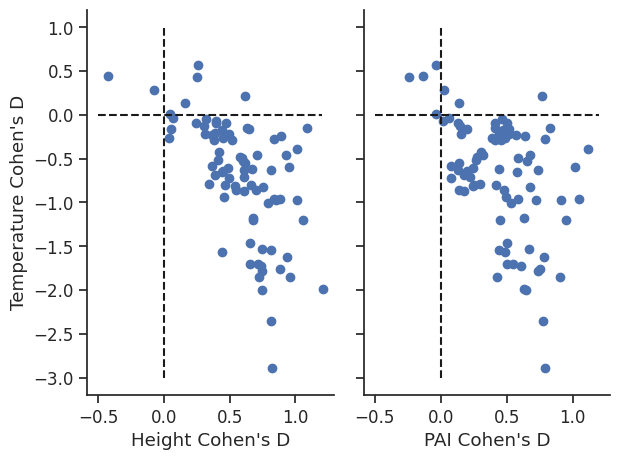

In [12]:
# Make a plot - effect size of Temp vs Effect size of Height & PAI
sns.set_theme(font_scale=1.1, style="ticks", rc=custom_params)

# This asks - can differences in height/pai account for differences in temp? 
fig, (a1, a2) = plt.subplots(1, 2, sharey=True)
a1.scatter(ESstats_height_allsites.cohensd, ESstats_allsites.cohensd)
a1.vlines(0, -3, 1, 'k', '--')
a1.hlines(0, -0.5, 1.2, 'k', '--')
a1.set_xlabel('Height Cohen\'s D')
a1.set_ylabel('Temperature Cohen\'s D')
a2.scatter(ESstats_PAI_allsites.cohensd, ESstats_allsites.cohensd)
a2.vlines(0, -3, 1, 'k', '--')
a2.hlines(0, -0.5, 1.2, 'k', '--')
a2.set_xlabel('PAI Cohen\'s D')
fig.tight_layout()
fig.savefig(f'{figdir}/Scatter_CohensDperImage_TemperaturexHeightandPAI.png', dpi=300)

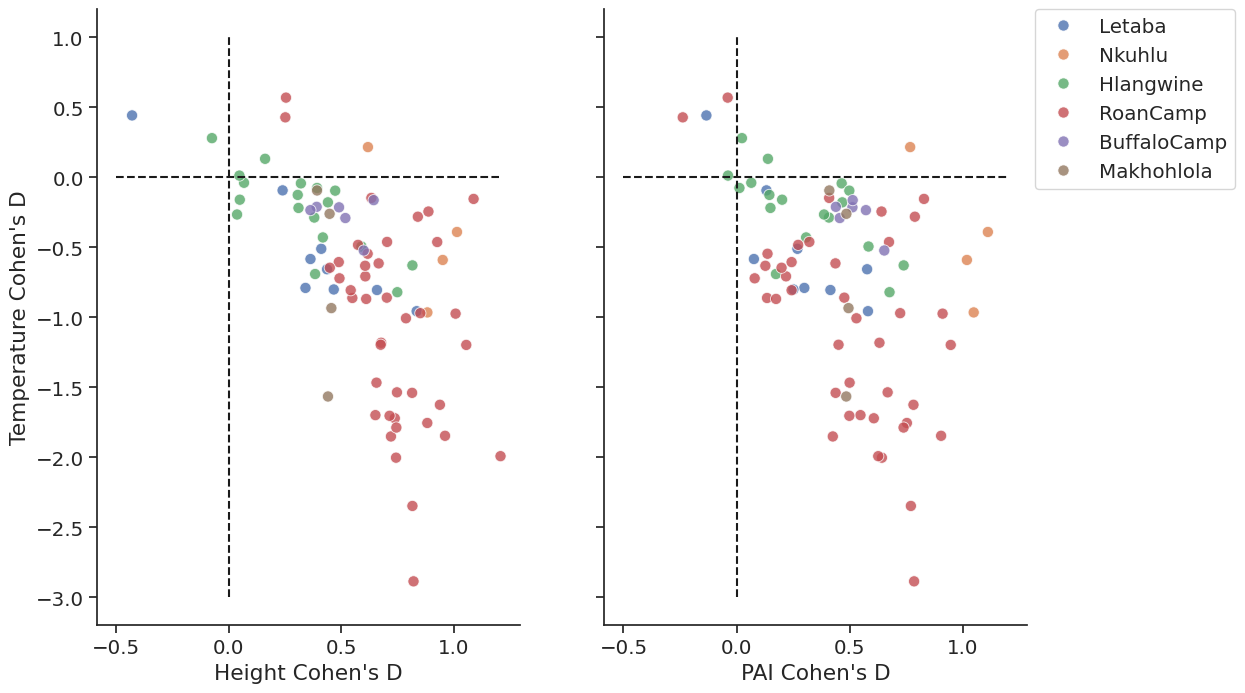

In [13]:
# Make a plot - effect size of Temp vs Effect size of Height & PAI
# This time with Sites labell

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_theme(font_scale=1.3, style="ticks", rc=custom_params)

# This asks - can differences in height/pai account for differences in temp? 
fig, (a1, a2) = plt.subplots(1, 2, sharey=True)
sns.scatterplot(x=ESstats_height_allsites.cohensd,
                y=ESstats_allsites.cohensd,
                hue=ESstats_allsites.site,
                ax=a1, legend=False, alpha=0.8, s=65)
a1.vlines(0, -3, 1, 'k', '--')
a1.hlines(0, -0.5, 1.2, 'k', '--')
a1.set_xlabel('Height Cohen\'s D')
a1.set_ylabel('Temperature Cohen\'s D')
sns.scatterplot(x=ESstats_PAI_allsites.cohensd,
                y=ESstats_allsites.cohensd,
                hue=ESstats_allsites.site,
                ax=a2, alpha=0.8, s=65)
a2.vlines(0, -3, 1, 'k', '--')
a2.hlines(0, -0.5, 1.2, 'k', '--')
a2.set_xlabel('PAI Cohen\'s D')
# fig.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.savefig(f'{figdir}/Scatter_CohensDperImage_TemperaturexHeightandPAI_bySite.png', dpi=300)


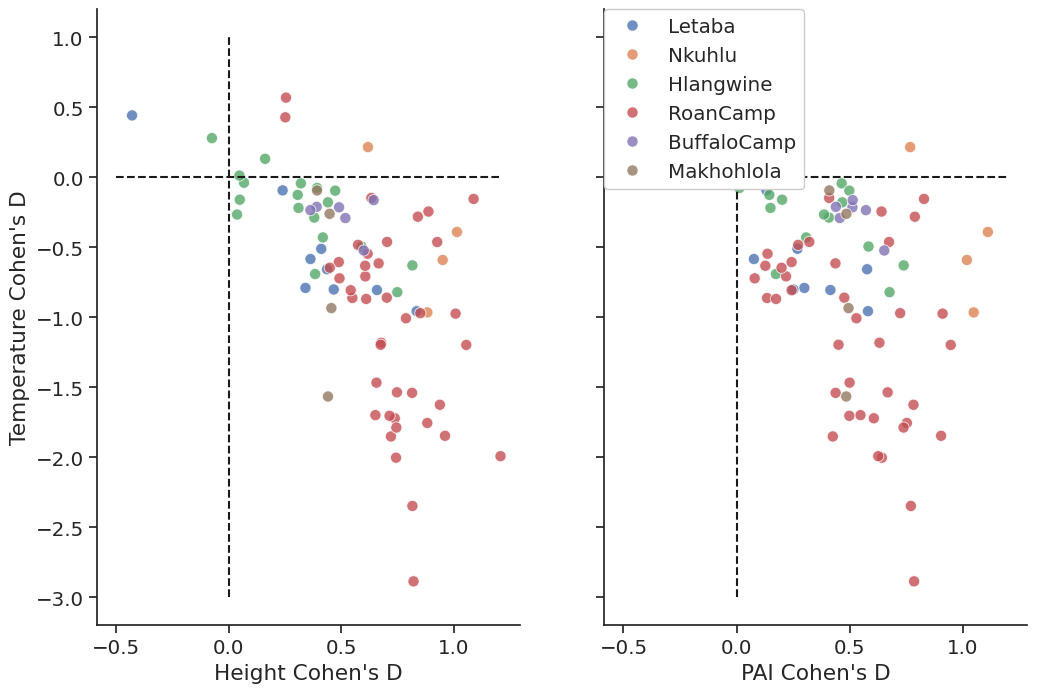

In [14]:
# Make a plot - effect size of Temp vs Effect size of Height & PAI
# This time with Sites labell

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_theme(font_scale=1.3, style="ticks", rc=custom_params)

# This asks - can differences in height/pai account for differences in temp? 
fig, (a1, a2) = plt.subplots(1, 2, sharey=True)
sns.scatterplot(x=ESstats_height_allsites.cohensd,
                y=ESstats_allsites.cohensd,
                hue=ESstats_allsites.site,
                ax=a1, legend=False, alpha=0.8, s=65)
a1.vlines(0, -3, 1, 'k', '--')
a1.hlines(0, -0.5, 1.2, 'k', '--')
a1.set_xlabel('Height Cohen\'s D')
a1.set_ylabel('Temperature Cohen\'s D')
sns.scatterplot(x=ESstats_PAI_allsites.cohensd,
                y=ESstats_allsites.cohensd,
                hue=ESstats_allsites.site,
                ax=a2, alpha=0.8, s=65)
a2.vlines(0, -3, 1, 'k', '--')
a2.hlines(0, -0.5, 1.2, 'k', '--')
a2.set_xlabel('PAI Cohen\'s D')
# fig.tight_layout()
plt.legend(bbox_to_anchor=(0, 1), loc='upper left', borderaxespad=0, framealpha=1.0)
fig.savefig(f'{figdir}/Scatter_CohensDperImage_TemperaturexHeightandPAI_bySite_withLEGEND.png', dpi=300)

/tmp/ipykernel_3125185/1571964836.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


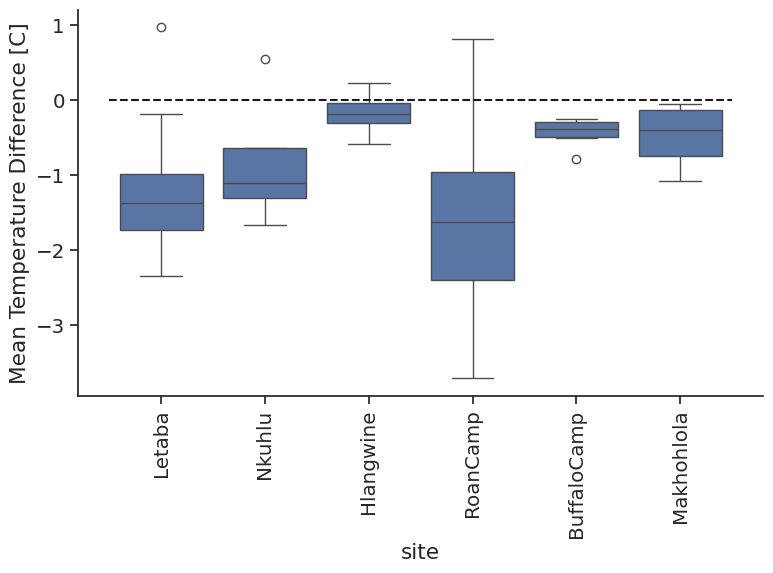

In [15]:

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 6]
sns.set_theme(font_scale=1.3, style="ticks", rc=custom_params)

# plt.rcParams.update({'font.size':11})
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_allsites, y="meandiff", x="site", ax=ax)
ax.set_ylabel('Mean Temperature Difference [C]')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.hlines(0, -0.5, 5.5, 'k', '--')
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_MeanDiffperImage_Temperature.png', dpi=300)

/tmp/ipykernel_3125185/347508484.py:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


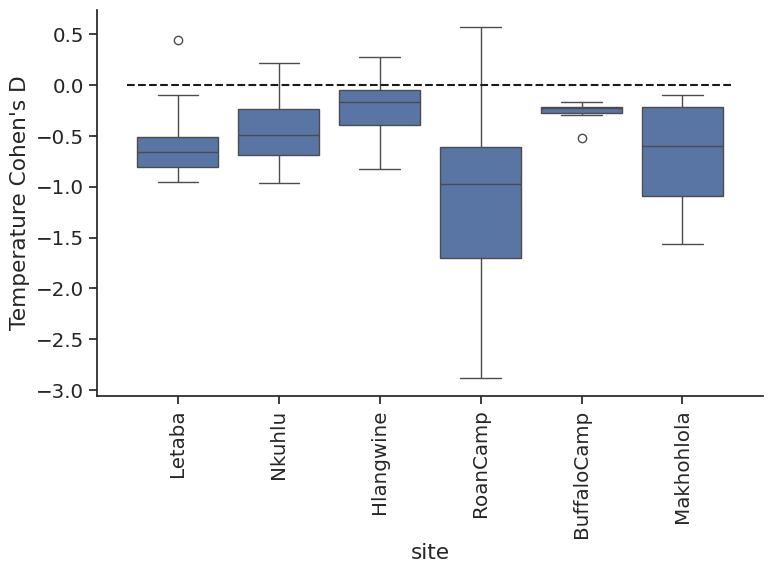

In [16]:
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_allsites, y="cohensd", x="site", ax=ax)
ax.set_ylabel('Temperature Cohen\'s D')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.hlines(0, -0.5, 5.5, 'k', '--')
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_CohensDperImage_Temperature.png', dpi=300)

/tmp/ipykernel_3125185/3584357119.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


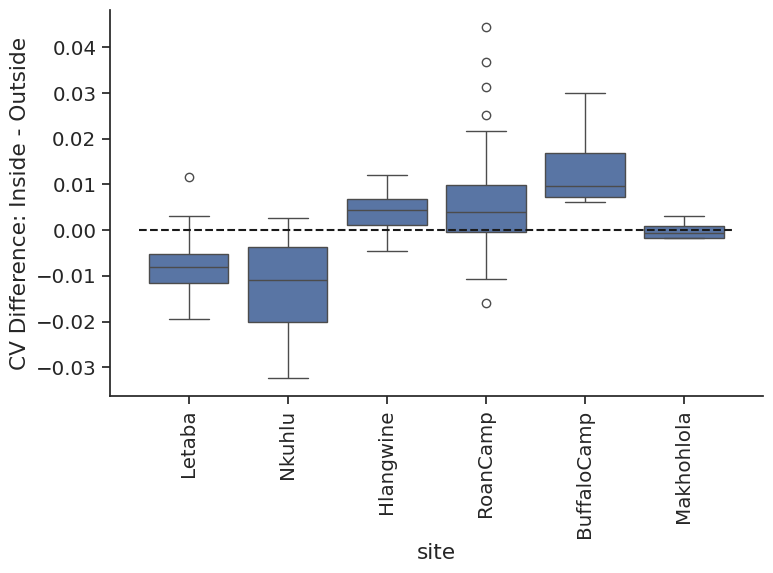

In [17]:
ax.set_ylabel('Mean Temperature Difference [C]')
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_allsites, y="CVdiff", x="site", ax=ax)
ax.set_ylabel('CV Difference: Inside - Outside')
ax.hlines(0, -0.5, 5.5, 'k', '--')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_CVDiffperImage_Temperature.png', dpi=300)

/tmp/ipykernel_3125185/722423423.py:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


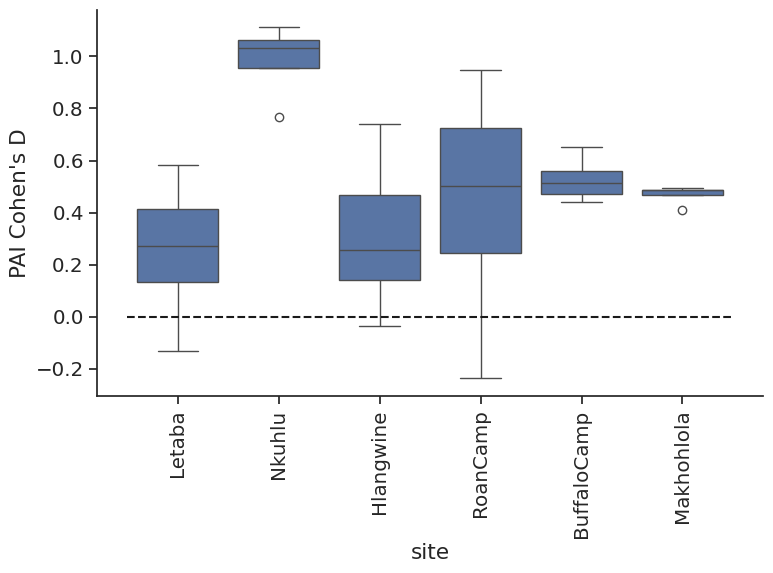

In [18]:
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_PAI_allsites, y="cohensd", x="site", ax=ax)
ax.set_ylabel('PAI Cohen\'s D')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.hlines(0, -0.5, 5.5, 'k', '--')
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_CohensDperImage_PAI.png', dpi=300)

/tmp/ipykernel_3125185/233736064.py:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


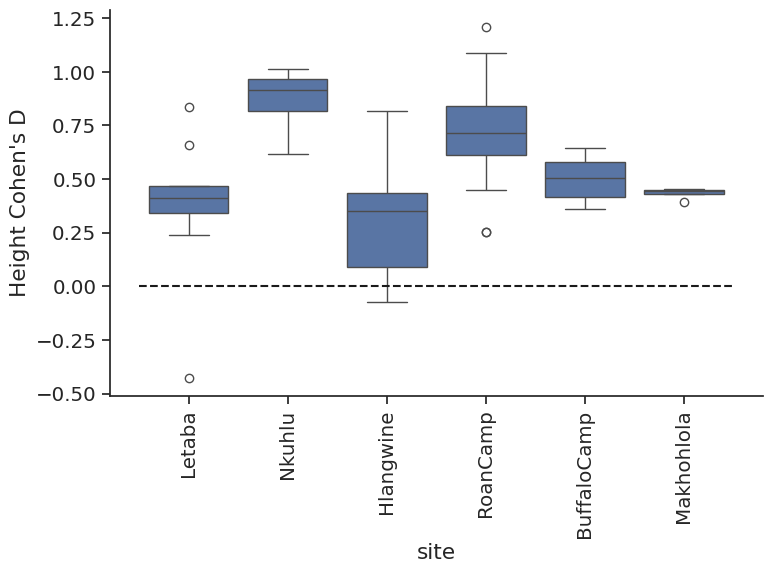

In [19]:
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_height_allsites, y="cohensd", x="site", ax=ax)
ax.set_ylabel('Height Cohen\'s D')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.hlines(0, -0.5, 5.5, 'k', '--')
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_CohensDperImage_Height.png', dpi=300)

/tmp/ipykernel_3125185/2376691702.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


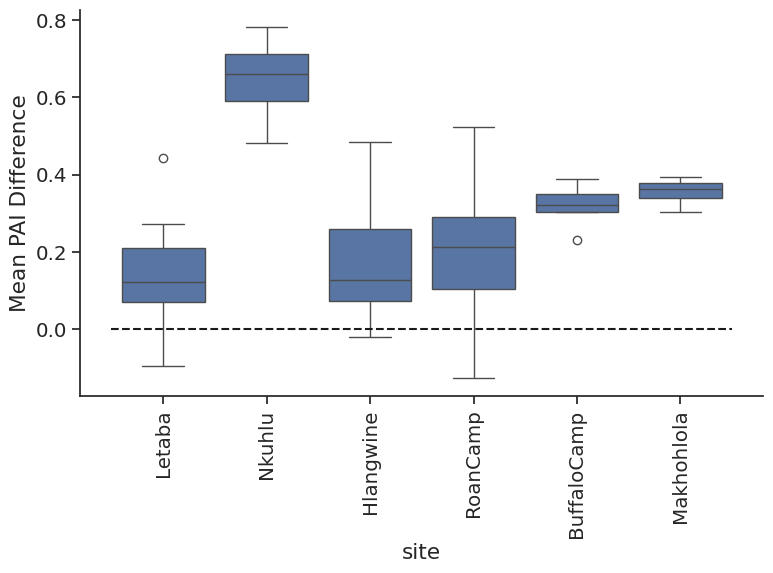

In [20]:
# plt.rcParams.update({'font.size':11})
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_PAI_allsites, y="meandiff", x="site", ax=ax)
ax.set_ylabel('Mean PAI Difference')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.hlines(0, -0.5, 5.5, 'k', '--')
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_MeanDiffperImage_PAI.png', dpi=300)

/tmp/ipykernel_3125185/2033695529.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


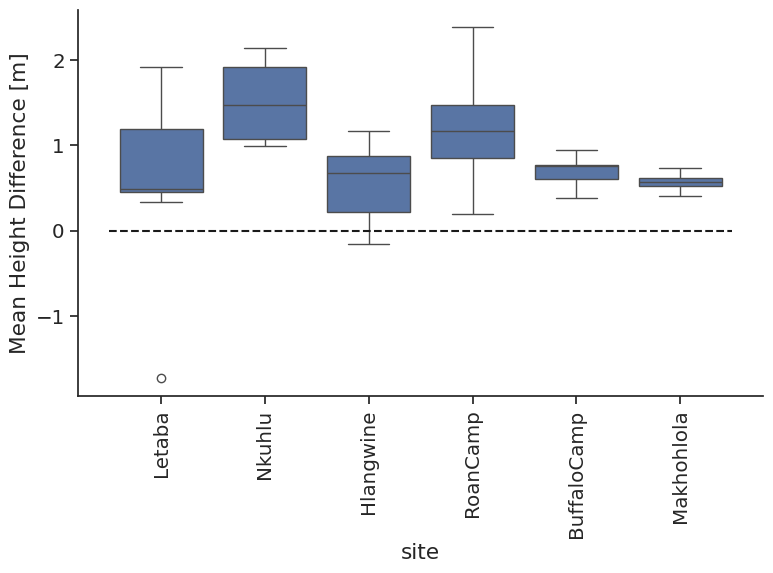

In [21]:
# plt.rcParams.update({'font.size':11})
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_height_allsites, y="meandiff", x="site", ax=ax)
ax.set_ylabel('Mean Height Difference [m]')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.hlines(0, -0.5, 5.5, 'k', '--')
fig.tight_layout()
fig.savefig(f'{figdir}/Boxplots_MeanDiffperImage_Height.png', dpi=300)

/tmp/ipykernel_3125185/1338558838.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


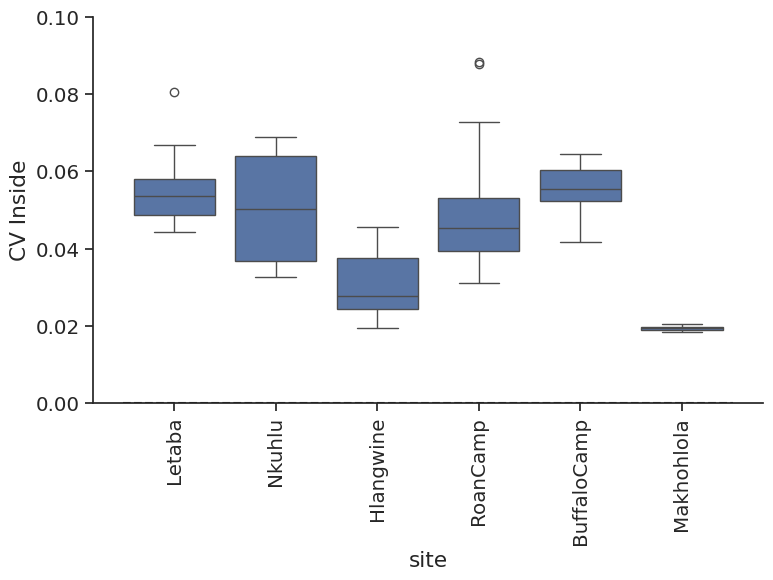

In [22]:

fig, ax = plt.subplots()
sns.boxplot(data=ESstats_allsites, y="CV_inside", x="site", ax=ax)
ax.set_ylabel('CV Inside')
ax.hlines(0, -0.5, 5.5, 'k', '--')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
fig.tight_layout()
ax.set_ylim(0, 0.1)
fig.savefig(f'{figdir}/Boxplots_CVInsideperImage_Temperature.png', dpi=300)

/tmp/ipykernel_3125185/747290437.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


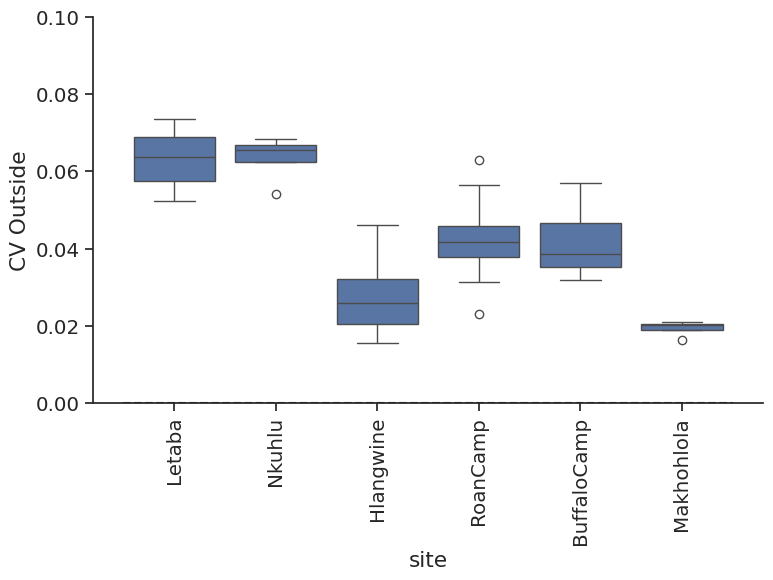

In [23]:
fig, ax = plt.subplots()
sns.boxplot(data=ESstats_allsites, y="CV_outside", x="site", ax=ax)
ax.set_ylabel('CV Outside')
ax.hlines(0, -0.5, 5.5, 'k', '--')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
fig.tight_layout()
ax.set_ylim(0, 0.1)
fig.savefig(f'{figdir}/Boxplots_CVOutsideperImage_Temperature.png', dpi=300)


In [24]:
ESstats_PAI_allsites.head()

,site,imgf,tstat,p,cohensd,meandiff,mean_inside,mean_outside,n_inside,n_outside,stddiff,std_inside,std_outside,CVdiff,CV_inside,CV_outside
0,Letaba,cam1-001-001236-0.tif,201.495484,0.0,0.299967,0.144184,0.462469,0.318285,902429,902429,0.021171,0.491135,0.469964,-0.414568,1.061986,1.476554
1,Letaba,cam1-001-001262-0.tif,69.659124,0.0,0.415356,0.208858,0.516728,0.307871,56253,56253,0.003283,0.504480,0.501197,-0.651649,0.976295,1.627945
2,Letaba,cam1-001-001380-0.tif,354.681432,0.0,0.581493,0.273204,0.516444,0.243239,744078,744078,0.071789,0.504355,0.432565,-0.801763,0.976592,1.778355
3,Letaba,cam1-001-001405-0.tif,80.081624,0.0,0.132446,0.070551,0.493982,0.423431,731165,731165,-0.075545,0.493559,0.569105,-0.344887,0.999145,1.344032
4,Letaba,cam1-001-001659-0.tif,138.974115,0.0,0.577729,0.442499,0.846488,0.403989,115731,115731,0.283121,0.894295,0.611173,-0.456371,1.056476,1.512847


In [25]:
### TBD - Add a section here to bring in the image times 
# Then, match the image times with the file times in ESstats
# Then, save out an es file 
# this is for fitting a model of effect size, and using time of day as a random effect
# 3/28/23



In [26]:
# # Make a plot - effect size of Temp vs Effect size of Height & PAI

# fig, (a1, a2) = plt.subplots(1, 2, sharey=True)
# a1.scatter(ESstats_allsites.cohensd, ESstats_height_allsites.cohensd)
# a1.set_xlabel('Height Cohen\'s D')
# a1.set_ylabel('Temperature Cohen\'s D')
# a2.scatter(ESstats_allsites.cohensd, ESstats_PAI_allsites.cohensd)
# a2.set_xlabel('PAI Cohen\'s D')

In [27]:
# 0.05/41
propimg_summary

site
BuffaloCamp    1.000000
Hlangwine      0.833333
Letaba         0.888889
Makhohlola     1.000000
Nkuhlu         0.600000
RoanCamp       0.951220
dtype: float64

In [28]:
propimg_summary_height

site
BuffaloCamp    1.000000
Hlangwine      0.944444
Letaba         0.888889
Makhohlola     1.000000
Nkuhlu         0.800000
RoanCamp       1.000000
dtype: float64

In [29]:
propimg_summary_PAI

site
BuffaloCamp    1.000000
Hlangwine      0.944444
Letaba         0.888889
Makhohlola     1.000000
Nkuhlu         0.800000
RoanCamp       0.951220
dtype: float64

In [30]:
ESstats_allsites.groupby(['site']).cohensd.describe()

,count,mean,std,min,25%,50%,75%,max
site,,,,,,,,
BuffaloCamp,6.0,-0.273153,0.129282,-0.523181,-0.277204,-0.224792,-0.212189,-0.163491
Hlangwine,18.0,-0.229869,0.288612,-0.820957,-0.394360,-0.169791,-0.051856,0.279387
Letaba,9.0,-0.528717,0.440646,-0.956642,-0.801495,-0.657110,-0.511199,0.441651
Makhohlola,4.0,-0.714039,0.674171,-1.565924,-1.092519,-0.597951,-0.219471,-0.094332
Nkuhlu,4.0,-0.432949,0.493505,-0.965484,-0.684484,-0.490857,-0.239322,0.215401
RoanCamp,41.0,-1.058720,0.734167,-2.886388,-1.699120,-0.970864,-0.606006,0.568772


In [31]:
ESstats_allsites.groupby(['site']).p.describe()

,count,mean,std,min,25%,50%,75%,max
site,,,,,,,,
BuffaloCamp,6.0,2.900324e-161,7.102401e-161,0.0,0.0,0.000000e+00,0.000000e+00,1.740194e-160
Hlangwine,18.0,2.137923e-09,9.070439e-09,0.0,0.0,0.000000e+00,1.191421e-210,3.848261e-08
Letaba,9.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
Makhohlola,4.0,2.029275e-181,0.000000e+00,0.0,0.0,1.391570e-245,2.029275e-181,8.117101e-181
Nkuhlu,4.0,3.710518e-210,0.000000e+00,0.0,0.0,0.000000e+00,3.710518e-210,1.484207e-209
RoanCamp,41.0,4.286189e-265,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,1.757338e-263


In [32]:
# Make an image polygon shapefile for each site
# added 12/16/22 to aid in the calculation of PAI per site
# allows for the calculation of PAI only over the image locations

import rioxarray as rioxr
from shapely.geometry import Polygon
import geopandas as gpd

# list of rectified image directories for each site, in order
# ['Letaba', 'Nkuhlu', 'Hlangwine', 'RoanCamp', 'BuffaloCamp', 'Makhohlola']
imgdirs = ['/n/holystore01/LABS/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/Letaba_EP/raster/ortho/Thermal/rect',
          '/n/holystore01/LABS/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/NkuluEP/raster/rectifiedimages/thermal',
          '/n/holystore01/LABS/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/HlangwineEP/raster/ortho/thermal/rect_whole_site_new',
          '/n/holystore01/LABS/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/Roan_CampEP/raster/thermal/rectified_images',
          '/n/holystore01/LABS/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/BuffCampEP_100mAltitude/raster/thermal/rectifiedimages',
          '/n/holystore01/LABS/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/MakhEP/raster/thermal/rectifiedimages']

# Loop through and calculate statistics, grouped by different variables
for s, imgd in zip(sites, imgdirs):
    
    df_pixels = pix_dict[s]
    
    imgfs = df_pixels.imgf.unique()
    
    fpaths = [f'{imgd}/{f}' for f in imgfs]
    
    geom_list = []
    
    # Loop through each image
    for fp in fpaths:

        # Load image
        img = rioxr.open_rasterio(fp,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'imgf':imgfs,
                                'imgpaths':fpaths,
                                'site':s,
                                'geometry':geom_list},
                               geometry='geometry',
                               crs='EPSG:32736')
    
    img_gdf.to_file(f'/n/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes/data/out/imageshapefiles/ImageExtents_{s}.shp')

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

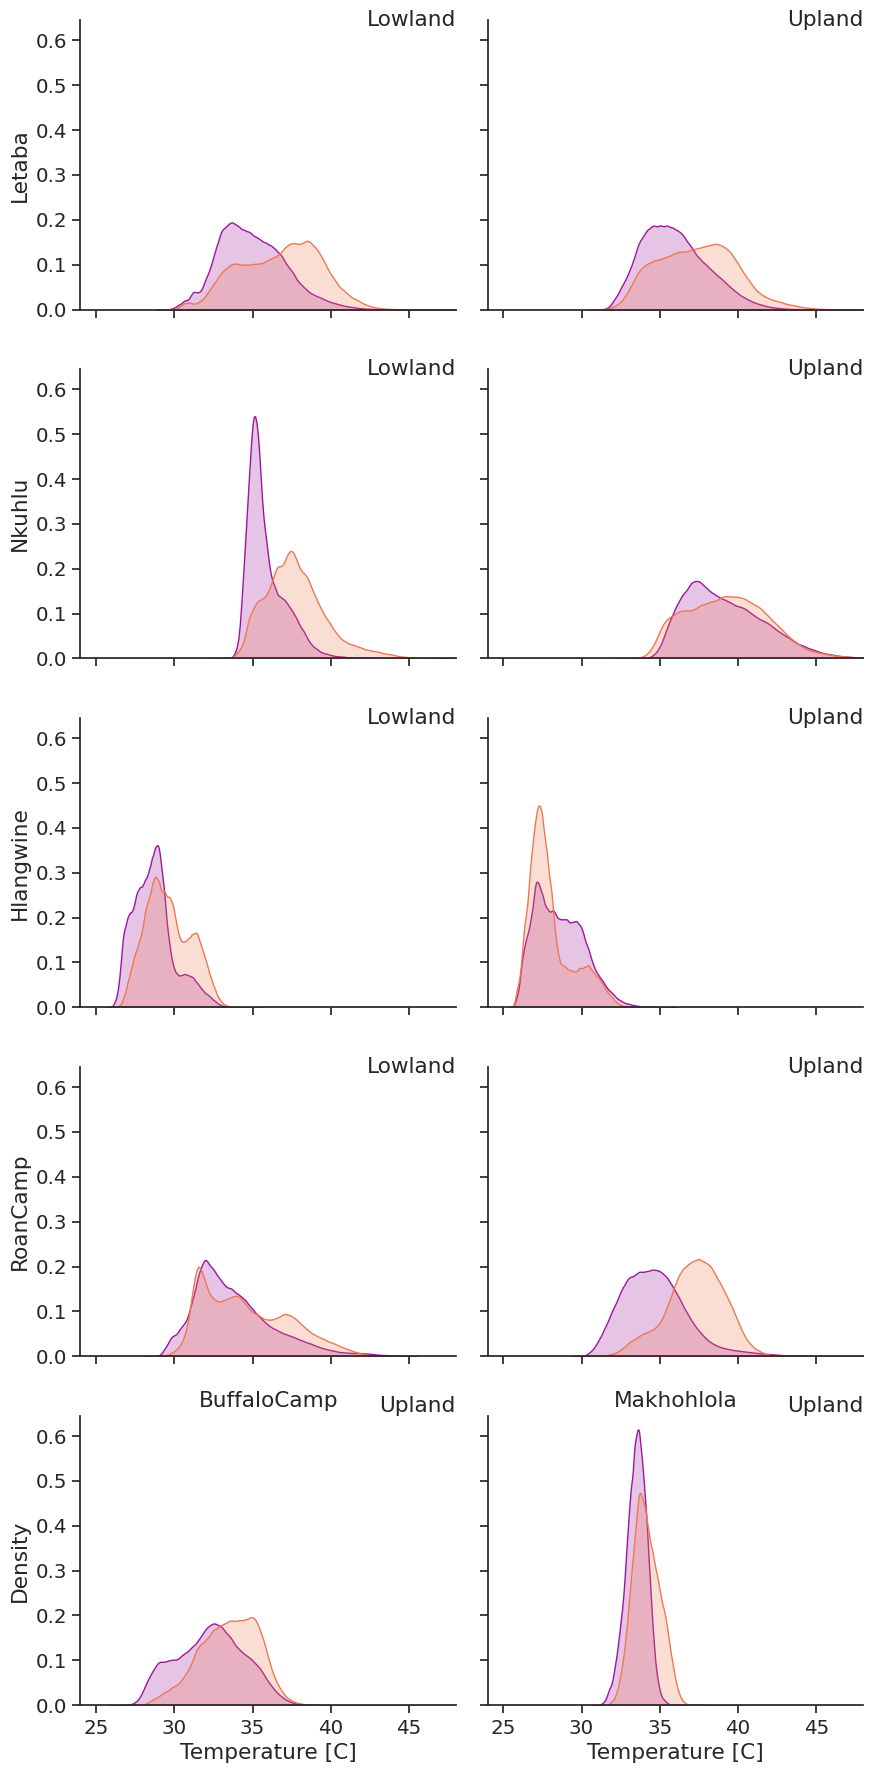

In [33]:
# Figure 2
# KDE Plots of Temp - Lowland, Upland

# plt.rcParams.update({'font.size': 11})
sns.set_theme(font_scale=1.3, style="ticks", rc=custom_params)
# plt.rcParams['figure.figsize'] = [12, 6]
# plt.rcParams.update({'font.size': 10})

# 5 row, 2 column (10 panel) grid
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10)) = plt.subplots(5, 2,
                                                                                  sharex=True,
                                                                                  sharey=True,
                                                                                  figsize=(9, 18))

for s, axes in zip(sites,
                   [(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), ax9, ax10]):
    
    df = pix_dict[s]
    
    if 'Topo' in df.columns:

        # Plot Upland and Lowland in seperate Columns
        for ul, ax in zip(['Lowland', 'Upland'], axes):

            sns.kdeplot(data=df.loc[df['Topo']==ul],
                        x='Temperature_eVeg',
                        hue='Exclosure',
                        ax=ax, 
                        palette='plasma_r',
                        hue_order=exclosure_hues,
                        fill=True,
                        legend=False,
                        common_norm=False)
            
            # Plot text in top right of figure axis
            # from: https://stackoverflow.com/questions/8482588/putting-text-in-top-left-corner-of-matplotlib-plot
            ax.text(1, 1, ul,
            horizontalalignment='right',
            verticalalignment='center',
            transform = ax.transAxes)
            
            if ul == 'Lowland':
                ax.set_ylabel(f'{s}')
                
            ax.set_xlim(24, 50)
            # ax.set_ylim(0, 0.55)
                
    else:
        
        # if s == 'BuffaloCamp':
        #     plotlegend = False
        # else:
        #     plotlegend = True
            
        sns.kdeplot(data=df,
                    x='Temperature_eVeg',
                    hue='Exclosure',
                    ax=axes, 
                    palette='plasma_r',
                    hue_order=exclosure_hues,
                    fill=True,
                    legend=False,
                    common_norm=False)
        
        # Plot text in top right of figure axis
        # from: https://stackoverflow.com/questions/8482588/putting-text-in-top-left-corner-of-matplotlib-plot
        axes.text(1, 1, 'Upland',
        horizontalalignment='right',
        verticalalignment='bottom',
        transform = axes.transAxes)
        
        axes.set_title(s)
        
#         axes.text(0, 1, s,
#         horizontalalignment='left',
#         verticalalignment='bottom',
#         transform = axes.transAxes)
        
        axes.set_xlabel('Temperature [C]')
        
        axes.set_xlim(24, 48)
        # axes.set_ylim(0, 0.4)
        
        # if plotlegend:
        #     sns.move_legend(axes, "upper left",
        #                     bbox_to_anchor=(1, 1), frameon=False)
        
fig.tight_layout()

fig.savefig(f'{figdir}/KDEPlot_TempbyExclosure_UpLowSplit_AllSites_Fig2.png', dpi=300)

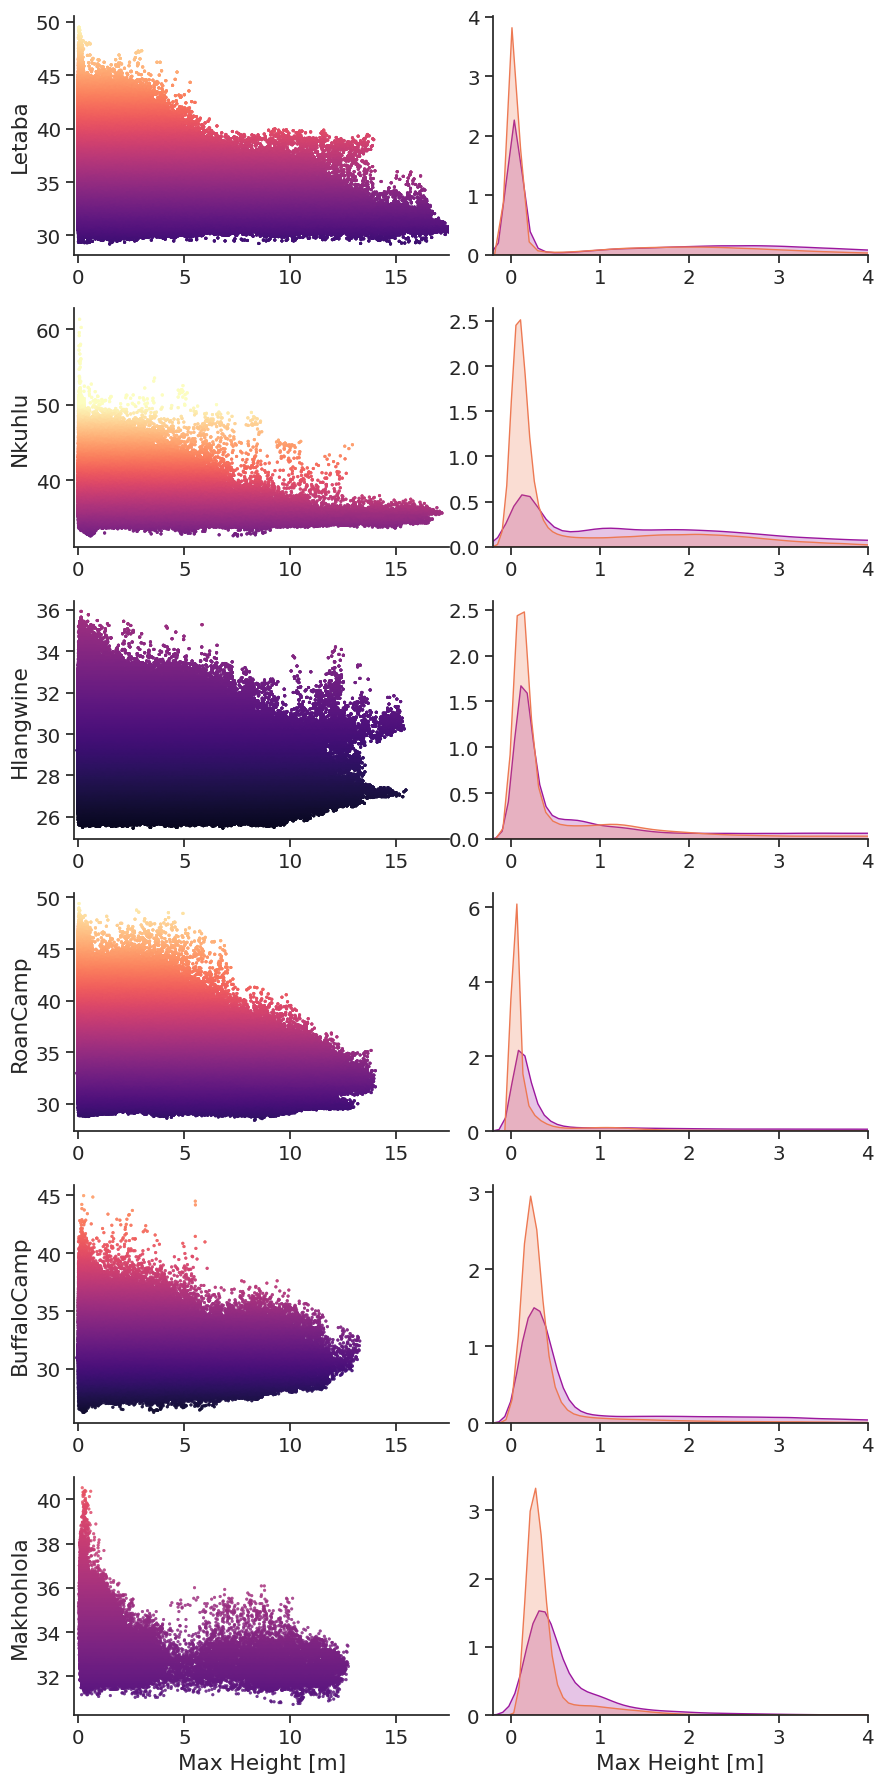

In [34]:
# Fitight_layout 3
# Scatter Plots of Height and temperature with Kde Plot

plt.rcParams.update({'font.size': 12})

# 6 rows, 2 column (12 panel) grid
fig3, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)) = plt.subplots(6, 2,
                                                                                    figsize=(9, 18))

for s, axes in zip(sites,
                   [(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)]):
# for s, axes in zip([sites[0]],
#                    [(ax1, ax2)]):
    
    df = pix_dict[s]
    
    # Add a filter here to only plot points with heights above 5 cm
    # df = df[df.Height > 0.05]
    
    # Scatter plot on axes A - Temp x Height
    axA = axes[0]

    a = axA.scatter(y=df.Temperature_eVeg,
                    x=df.Height,
                    c=df.Temperature_eVeg,
                    alpha=0.6, cmap='magma', s=5,
                    marker='o', edgecolors='none',
                    vmin=24, vmax=50)
    
    # ,
                    # vmin=24, vmax=48

    # fig.colorbar(a, shrink=0.7, ax=axA)
    # label='Temperature [C]',

    axA.set_xlim(-0.2, 17.5)

    axA.set_ylabel(s)
    # axA.text(0, 1, s,
    # horizontalalignment='left',
    # verticalalignment='center',
    # transform = axA.transAxes)

    # KDE plot on axes B - Height by Exclosure
    axB = axes[1]
    
    # # Only plot a legend for the first one
    # plotlegend = False
    # if s == 'Letaba':
    #     plotlegend = True
    
    sns.kdeplot(data=df,
                x='Height',
                hue='Exclosure',
                ax=axB,
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=False,
                common_norm=False)

    axB.set_xlim(-0.2, 4)
    
    axB.set_ylabel('')
    
    # if s == 'RoanCamp':
    #     axB.set_ylabel(f'Kernel Density Estimate')
    # else:
    #     axB.set_ylabel('')
    
#     if plotlegend:
#         # sns.move_legend(ax, "upper left",
#         #                 bbox_to_anchor=(1, 1), frameon=False)
        
#         plt.legend(bbox_to_anchor=(1.02, 0.15),
#                    loc='upper left',
#                    borderaxespad=0)
        
    if s == 'Makhohlola':
        axA.set_xlabel('Max Height [m]')
        axB.set_xlabel('Max Height [m]')
    else:
        axB.set_xlabel('')
        
fig3.tight_layout()

fig3.savefig(f'{figdir}/ScatterKDEGrid_HeightxTemp_UpLowSplit_AllSites_Fig3_4mXLimited.png', dpi=300)

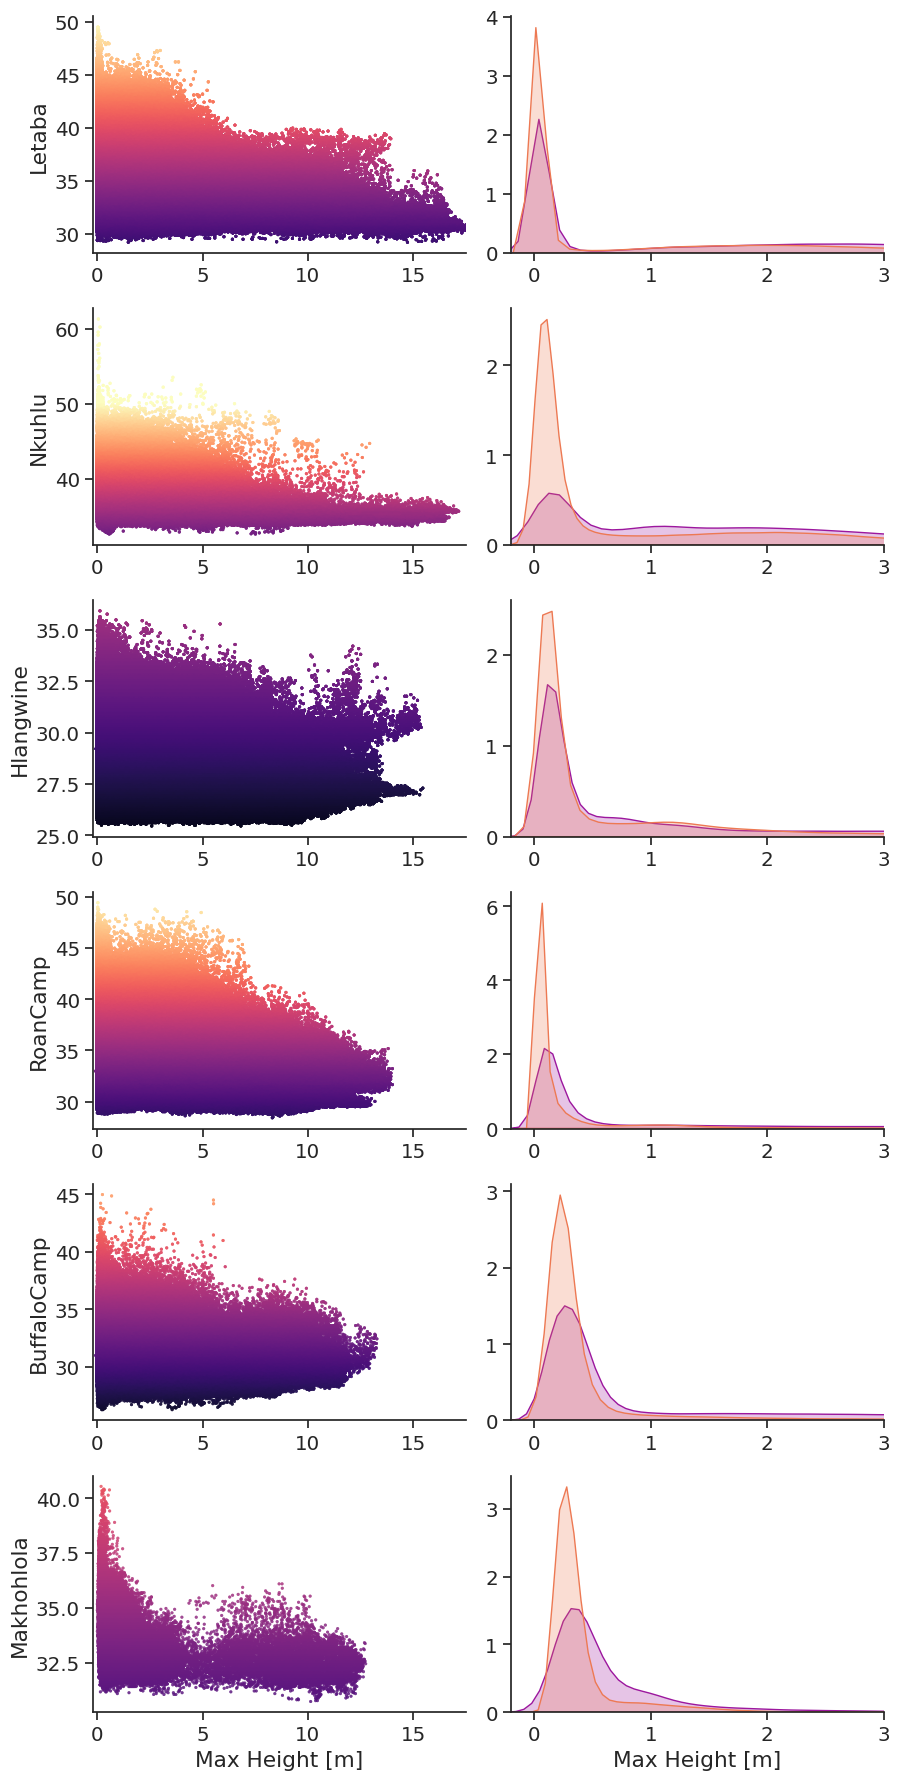

In [35]:
# Fitight_layout 3
# Scatter Plots of Height and temperature with Kde Plot

plt.rcParams.update({'font.size': 13})

# 6 rows, 2 column (12 panel) grid
fig3, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)) = plt.subplots(6, 2,
                                                                                    figsize=(9, 18))

for s, axes in zip(sites,
                   [(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)]):
# for s, axes in zip([sites[0]],
#                    [(ax1, ax2)]):
    
    df = pix_dict[s]
    
    # Add a filter here to only plot points with heights above 5 cm
    # df = df[df.Height > 0.05]
    
    # Scatter plot on axes A - Temp x Height
    axA = axes[0]

    a = axA.scatter(y=df.Temperature_eVeg,
                    x=df.Height,
                    c=df.Temperature_eVeg,
                    alpha=0.6, cmap='magma', s=5,
                    marker='o', edgecolors='none',
                    vmin=24, vmax=50)
    
    # ,
                    # vmin=24, vmax=48

    # fig.colorbar(a, shrink=0.7, ax=axA)
    # label='Temperature [C]',

    axA.set_xlim(-0.2, 17.5)

    axA.set_ylabel(s)
    # axA.text(0, 1, s,
    # horizontalalignment='left',
    # verticalalignment='center',
    # transform = axA.transAxes)

    # KDE plot on axes B - Height by Exclosure
    axB = axes[1]
    
    # # Only plot a legend for the first one
    # plotlegend = False
    # if s == 'Letaba':
    #     plotlegend = True
    
    sns.kdeplot(data=df,
                x='Height',
                hue='Exclosure',
                ax=axB,
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=False,
                common_norm=False)

    axB.set_xlim(-0.2, 3)
    
    axB.set_ylabel('')
    
    # if s == 'RoanCamp':
    #     axB.set_ylabel(f'Kernel Density Estimate')
    # else:
    #     axB.set_ylabel('')
    
#     if plotlegend:
#         # sns.move_legend(ax, "upper left",
#         #                 bbox_to_anchor=(1, 1), frameon=False)
        
#         plt.legend(bbox_to_anchor=(1.02, 0.15),
#                    loc='upper left',
#                    borderaxespad=0)
        
    if s == 'Makhohlola':
        axA.set_xlabel('Max Height [m]')
        axB.set_xlabel('Max Height [m]')
    else:
        axB.set_xlabel('')
        
fig3.tight_layout()

fig3.savefig(f'{figdir}/ScatterKDEGrid_HeightxTemp_UpLowSplit_AllSites_Fig3_3mXLimited.png', dpi=300)

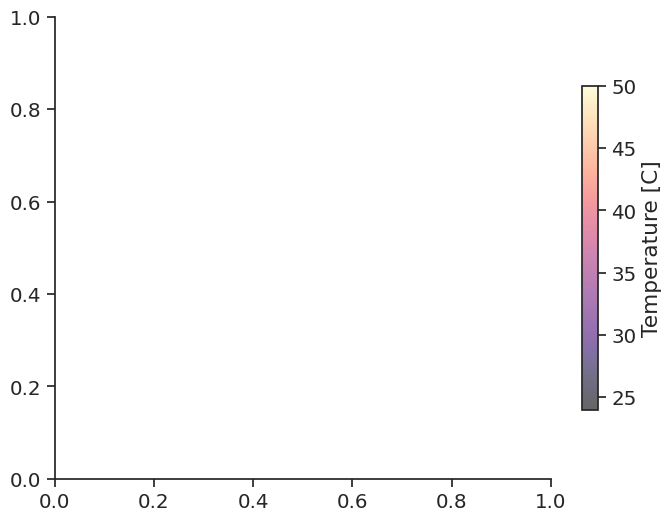

In [36]:
fig, ax = plt.subplots()
fig.colorbar(a, shrink=0.7, ax=ax, label='Temperature [C]')
fig.savefig(f'{figdir}/Colorbar_Fig3.png')

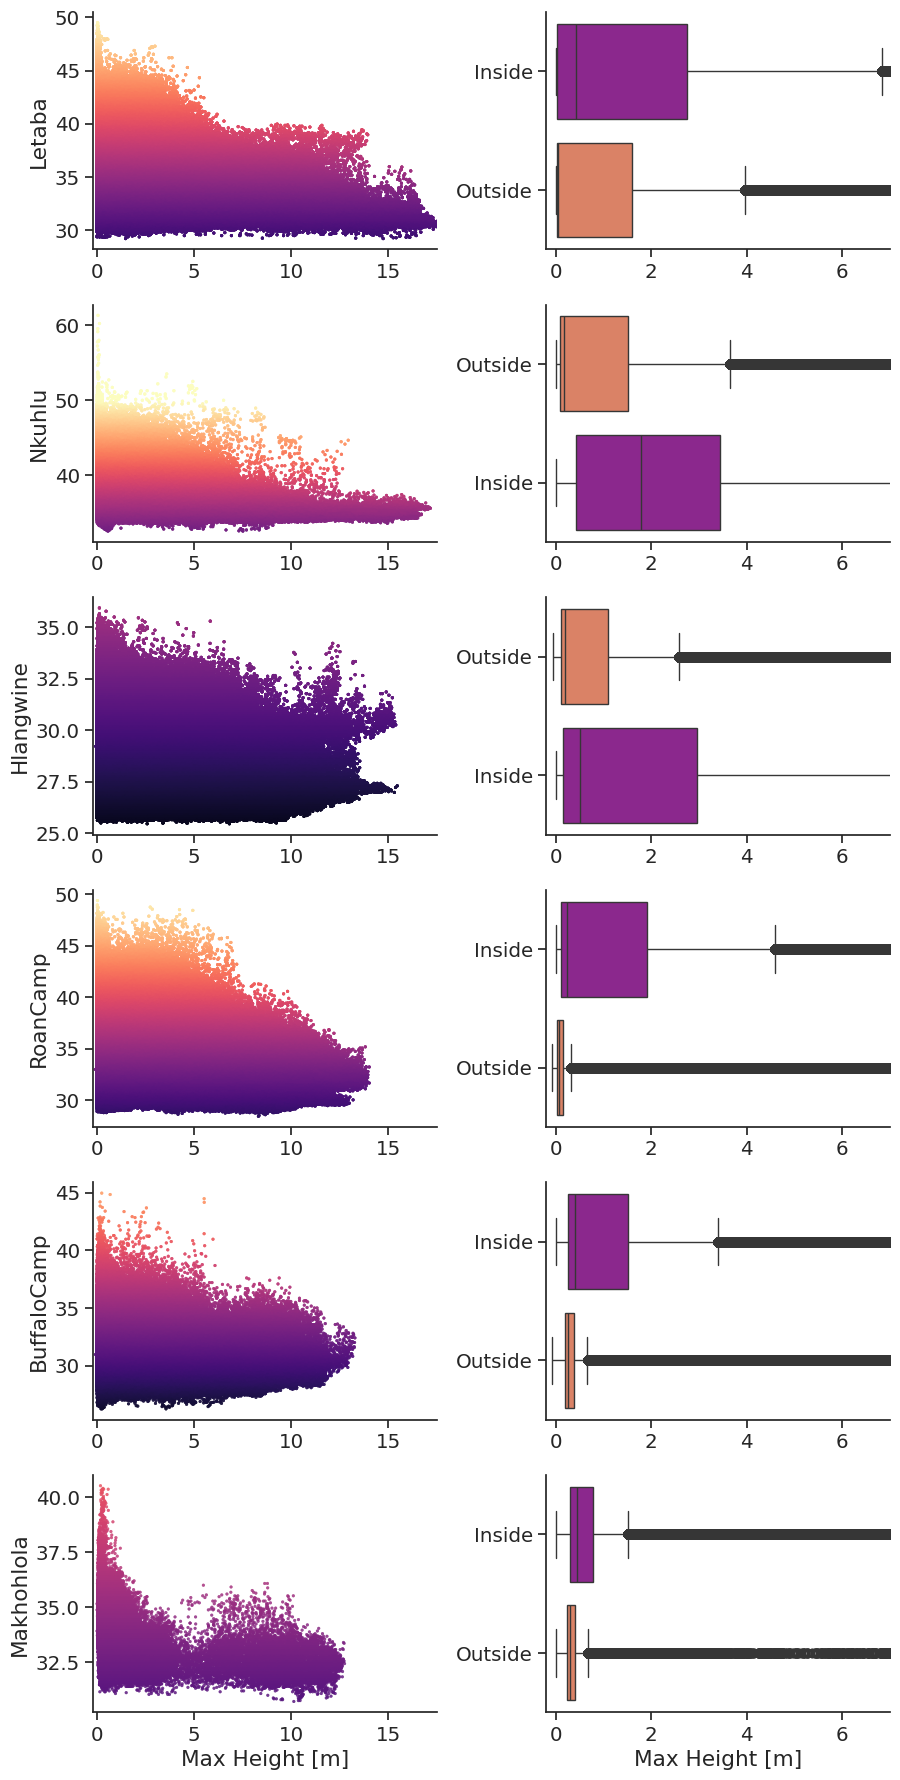

In [37]:
# Fitight_layout 3
# Scatter Plots of Height and temperature with BOXPLOT

plt.rcParams.update({'font.size': 13})

# 6 rows, 2 column (12 panel) grid
fig3, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)) = plt.subplots(6, 2,
                                                                                    figsize=(9, 18))

for s, axes in zip(sites,
                   [(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)]):
# for s, axes in zip([sites[0]],
#                    [(ax1, ax2)]):
    
    df = pix_dict[s]
    
    # Add a filter here to only plot points with heights above 5 cm
    # df = df[df.Height > 0.05]
    
    # Scatter plot on axes A - Temp x Height
    axA = axes[0]

    a = axA.scatter(y=df.Temperature_eVeg,
                    x=df.Height,
                    c=df.Temperature_eVeg,
                    alpha=0.6, cmap='magma', s=5,
                    marker='o', edgecolors='none',
                    vmin=24, vmax=50)
    
    # ,
                    # vmin=24, vmax=48

    # fig.colorbar(a, shrink=0.7, ax=axA)
    # label='Temperature [C]',

    axA.set_xlim(-0.2, 17.5)

    axA.set_ylabel(s)
    # axA.text(0, 1, s,
    # horizontalalignment='left',
    # verticalalignment='center',
    # transform = axA.transAxes)

    # KDE plot on axes B - Height by Exclosure
    axB = axes[1]
    
    # # Only plot a legend for the first one
    # plotlegend = False
    # if s == 'Letaba':
    #     plotlegend = True
    
    sns.boxplot(data=df,
                x='Height',
                y='Exclosure',
                hue='Exclosure',
                ax=axB,
                palette='plasma_r',
                hue_order=exclosure_hues)

    axB.set_xlim(-0.2, 7)
    
    axB.set_ylabel('')
    
    axB.legend([],[], frameon=False)
    
    # if s == 'RoanCamp':
    #     axB.set_ylabel(f'Kernel Density Estimate')
    # else:
    #     axB.set_ylabel('')
    
#     if plotlegend:
#         # sns.move_legend(ax, "upper left",
#         #                 bbox_to_anchor=(1, 1), frameon=False)
        
#         plt.legend(bbox_to_anchor=(1.02, 0.15),
#                    loc='upper left',
#                    borderaxespad=0)
        
    if s == 'Makhohlola':
        axA.set_xlabel('Max Height [m]')
        axB.set_xlabel('Max Height [m]')
    else:
        axB.set_xlabel('')
        
fig3.tight_layout()

fig3.savefig(f'{figdir}/ScatterBoxplotGrid_HeightxTemp_UpLowSplit_AllSites_Fig3.png', dpi=300)

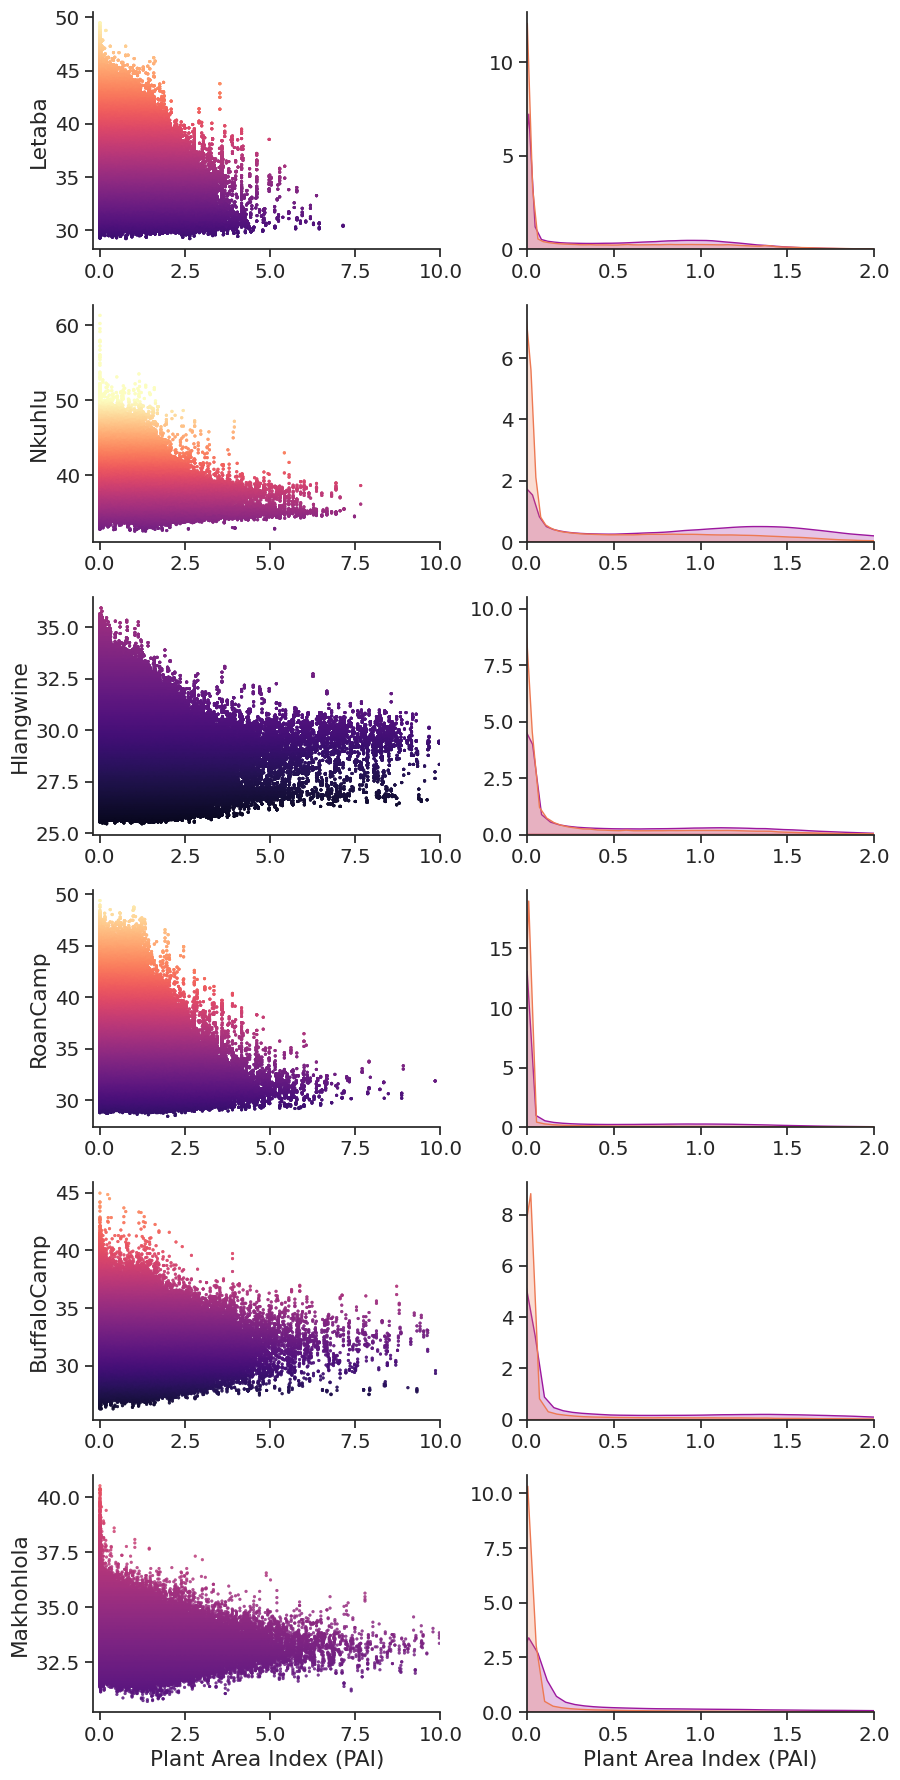

In [38]:
# Scatter and KDE plots of PAI and temperature

plt.rcParams.update({'font.size': 13})

# 6 rows, 2 column (12 panel) grid
fig3, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)) = plt.subplots(6, 2,
                                                                                    figsize=(9, 18))

for s, axes in zip(sites,
                   [(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)]):
    
    df = pix_dict[s]
    
    # Add a filter here to only plot points with heights above 5 cm
    # df = df[df.Height > 0.05]
    
    # Scatter plot on axes A - Temp x Height
    axA = axes[0]

    a = axA.scatter(y=df.Temperature_eVeg,
                    x=df.PAI,
                    c=df.Temperature_eVeg,
                    alpha=0.6, cmap='magma', s=5,
                    marker='o', edgecolors='none',
                    vmin=24, vmax=50)
    
    # ,
                    # vmin=24, vmax=48

    # fig.colorbar(a, shrink=0.7, ax=axA)
    # label='Temperature [C]',

    axA.set_xlim(-0.2, 10)

    axA.set_ylabel(s)
    # axA.text(0, 1, s,
    # horizontalalignment='left',
    # verticalalignment='center',
    # transform = axA.transAxes)

    # KDE plot on axes B - Height by Exclosure
    axB = axes[1]
    
    # # Only plot a legend for the first one
    # plotlegend = False
    # if s == 'Letaba':
    #     plotlegend = True
    
    sns.kdeplot(data=df,
                x='PAI',
                hue='Exclosure',
                ax=axB,
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=False,
                common_norm=False)

    axB.set_xlim(0, 2)
    
    axB.set_ylabel('')
    
    # if s == 'RoanCamp':
    #     axB.set_ylabel(f'Kernel Density Estimate')
    # else:
    #     axB.set_ylabel('')
    
#     if plotlegend:
#         # sns.move_legend(ax, "upper left",
#         #                 bbox_to_anchor=(1, 1), frameon=False)
        
#         plt.legend(bbox_to_anchor=(1.02, 0.15),
#                    loc='upper left',
#                    borderaxespad=0)
        
    if s == 'Makhohlola':
        axA.set_xlabel('Plant Area Index (PAI)')
        axB.set_xlabel('Plant Area Index (PAI)')
    else:
        axB.set_xlabel('')
        
fig3.tight_layout()

fig3.savefig(f'{figdir}/ScatterKDEGrid_PAIxTemp_UpLowSplit_AllSites.png', dpi=300)

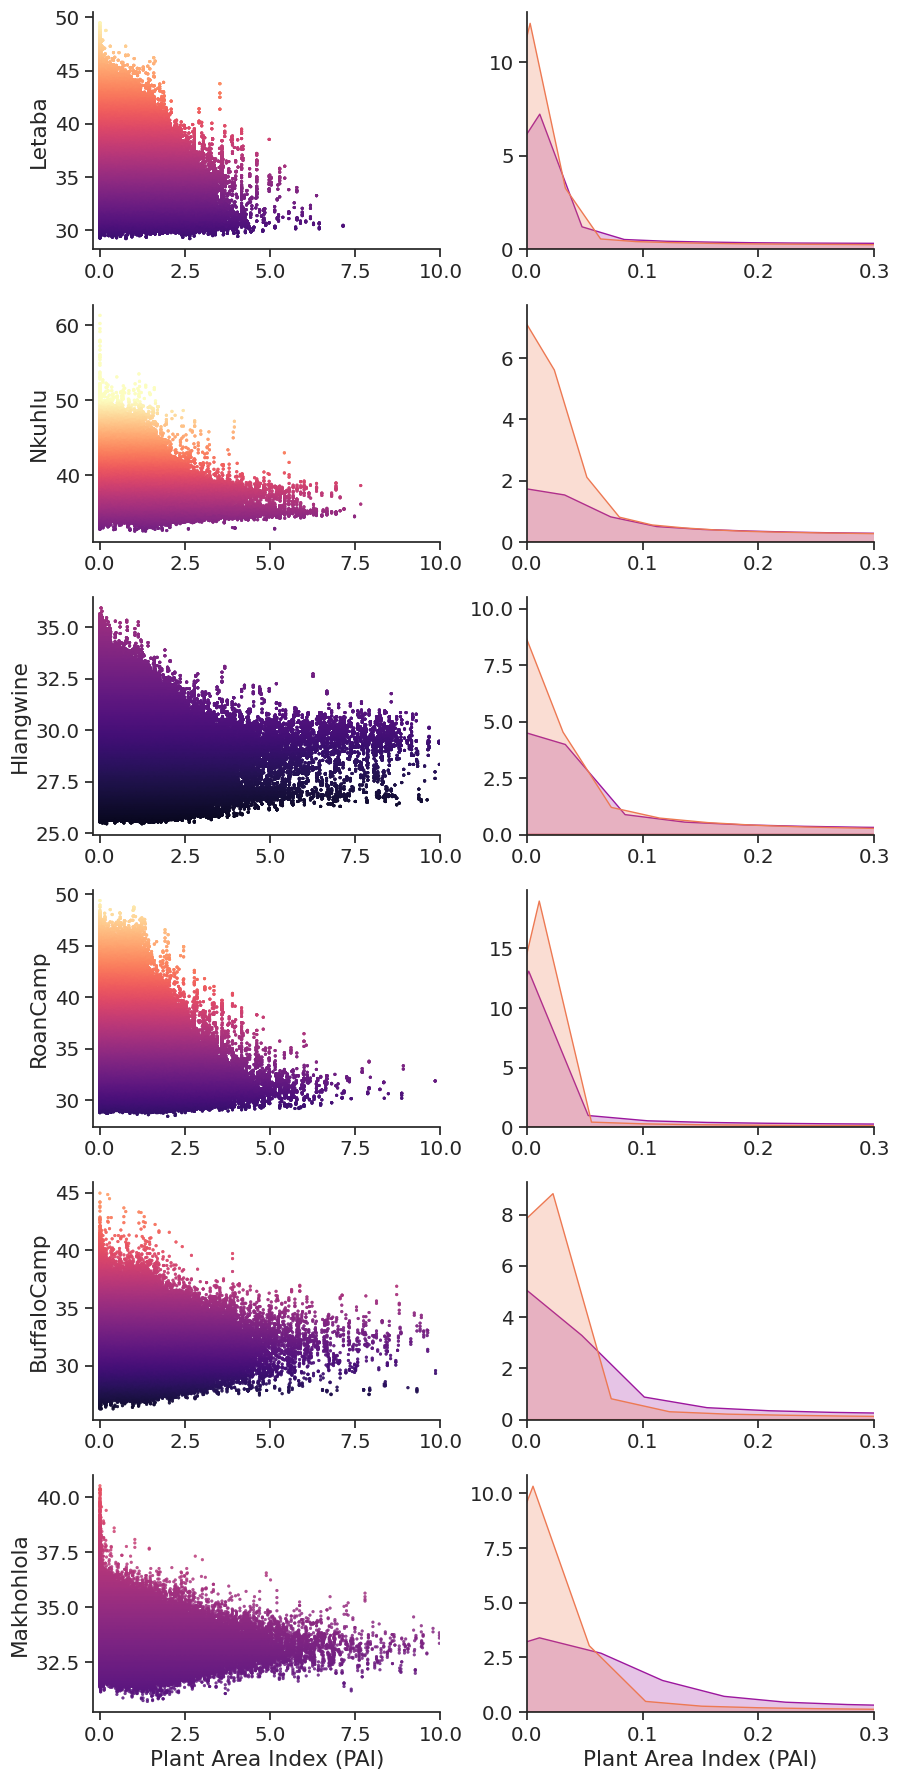

In [39]:
# XLIMITED version
# Scatter and KDE plots of PAI and temperature

plt.rcParams.update({'font.size': 13})

# 6 rows, 2 column (12 panel) grid
fig3, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)) = plt.subplots(6, 2,
                                                                                    figsize=(9, 18))

for s, axes in zip(sites,
                   [(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12)]):
    
    df = pix_dict[s]
    
    # Add a filter here to only plot points with heights above 5 cm
    # df = df[df.Height > 0.05]
    
    # Scatter plot on axes A - Temp x Height
    axA = axes[0]

    a = axA.scatter(y=df.Temperature_eVeg,
                    x=df.PAI,
                    c=df.Temperature_eVeg,
                    alpha=0.6, cmap='magma', s=5,
                    marker='o', edgecolors='none',
                    vmin=24, vmax=50)
    
    # ,
                    # vmin=24, vmax=48

    # fig.colorbar(a, shrink=0.7, ax=axA)
    # label='Temperature [C]',

    axA.set_xlim(-0.2, 10)

    axA.set_ylabel(s)
    # axA.text(0, 1, s,
    # horizontalalignment='left',
    # verticalalignment='center',
    # transform = axA.transAxes)

    # KDE plot on axes B - Height by Exclosure
    axB = axes[1]
    
    # # Only plot a legend for the first one
    # plotlegend = False
    # if s == 'Letaba':
    #     plotlegend = True
    
    sns.kdeplot(data=df,
                x='PAI',
                hue='Exclosure',
                ax=axB,
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=False,
                common_norm=False)

    axB.set_xlim(0, 0.3)
    
    axB.set_ylabel('')
    
    # if s == 'RoanCamp':
    #     axB.set_ylabel(f'Kernel Density Estimate')
    # else:
    #     axB.set_ylabel('')
    
#     if plotlegend:
#         # sns.move_legend(ax, "upper left",
#         #                 bbox_to_anchor=(1, 1), frameon=False)
        
#         plt.legend(bbox_to_anchor=(1.02, 0.15),
#                    loc='upper left',
#                    borderaxespad=0)
        
    if s == 'Makhohlola':
        axA.set_xlabel('Plant Area Index (PAI)')
        axB.set_xlabel('Plant Area Index (PAI)')
    else:
        axB.set_xlabel('')
        
fig3.tight_layout()

fig3.savefig(f'{figdir}/ScatterKDEGrid_PAIxTemp_UpLowSplit_AllSites_xlimited.png', dpi=300)

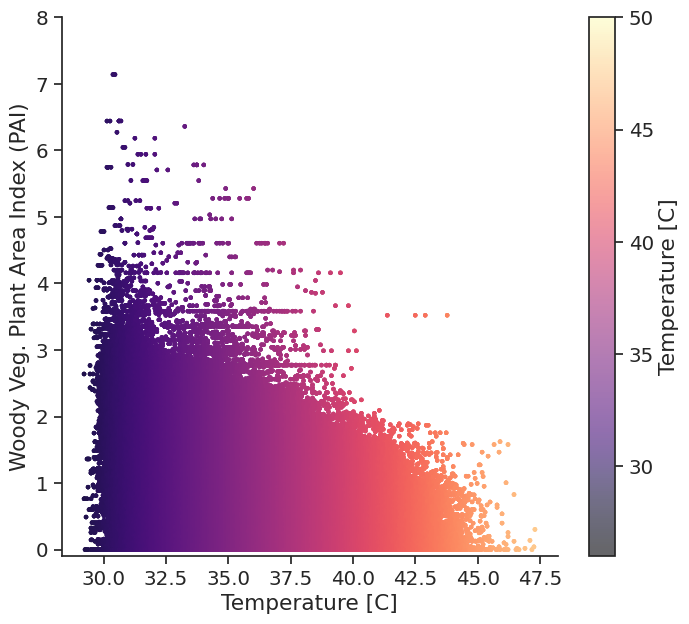

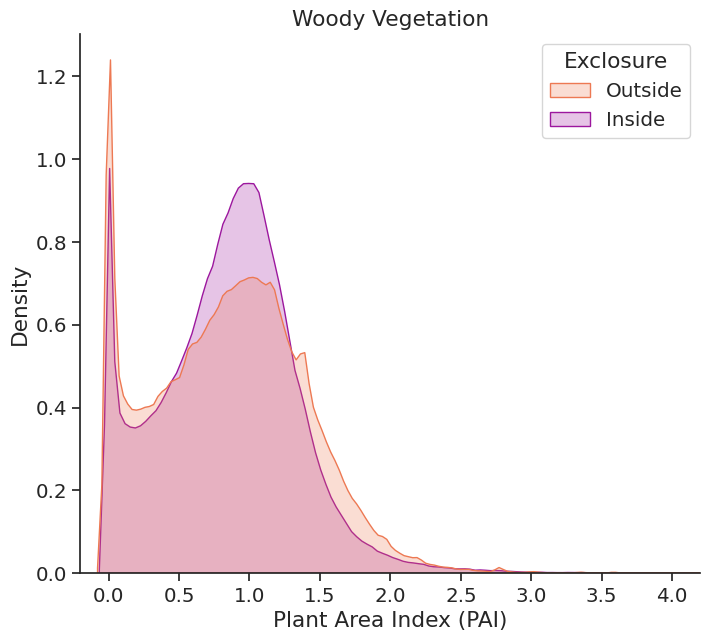

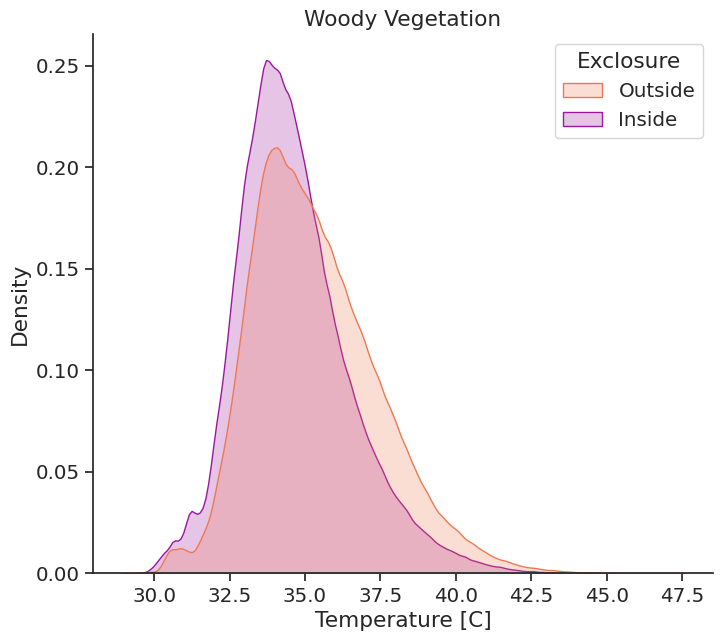

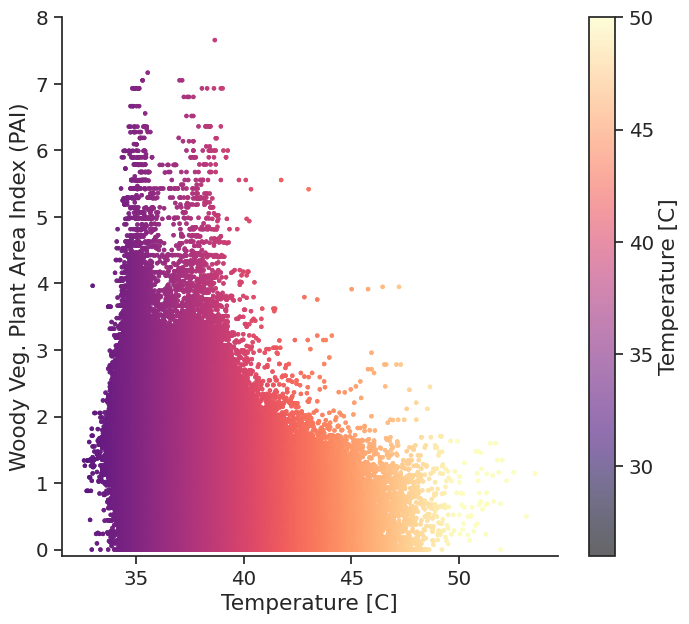

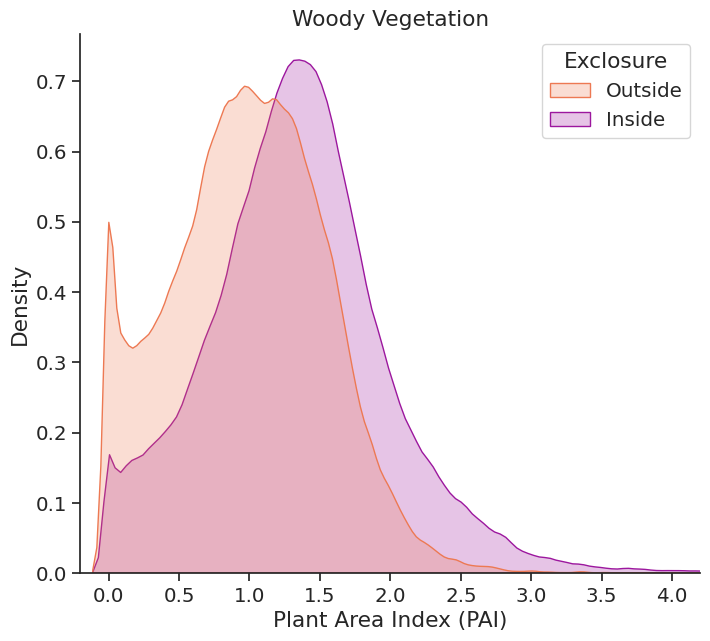

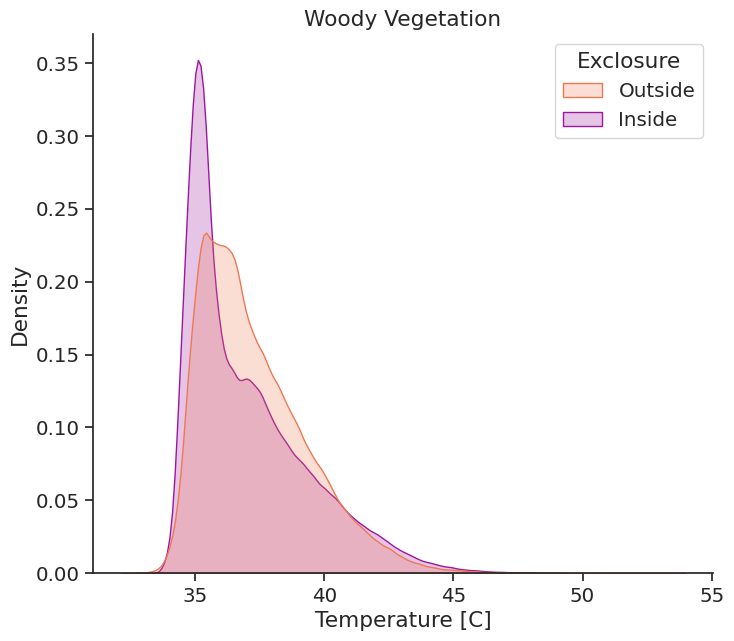

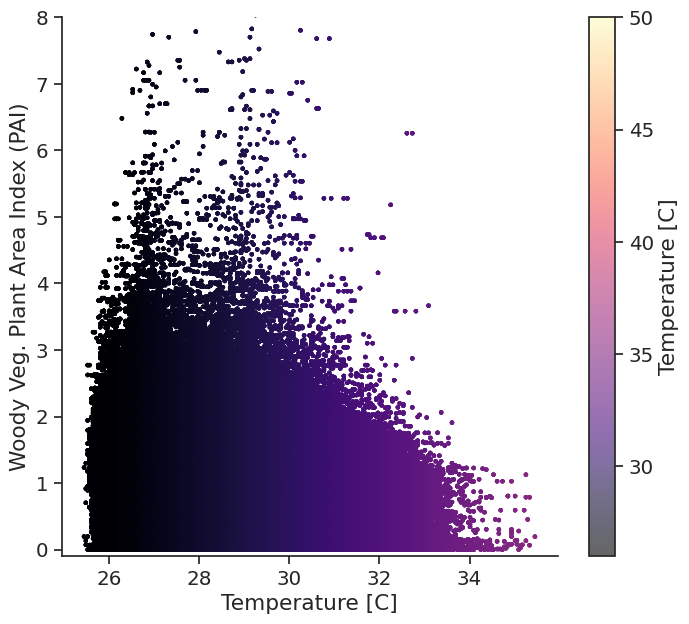

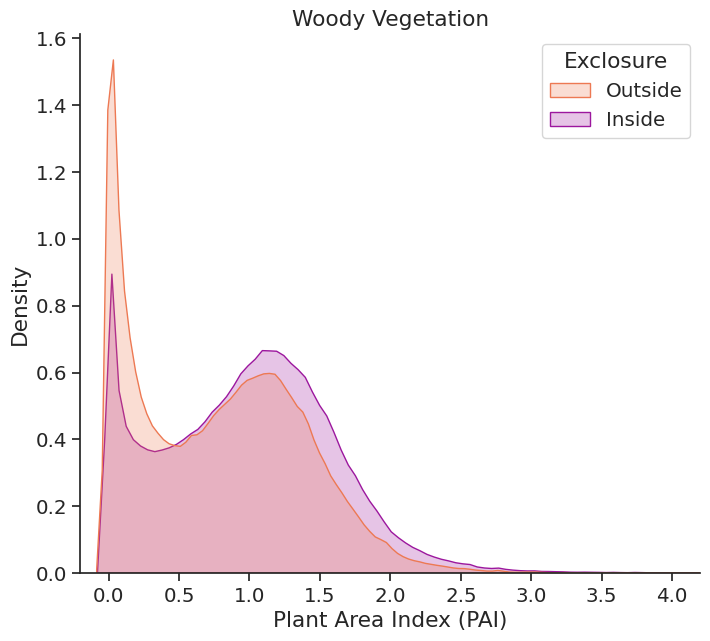

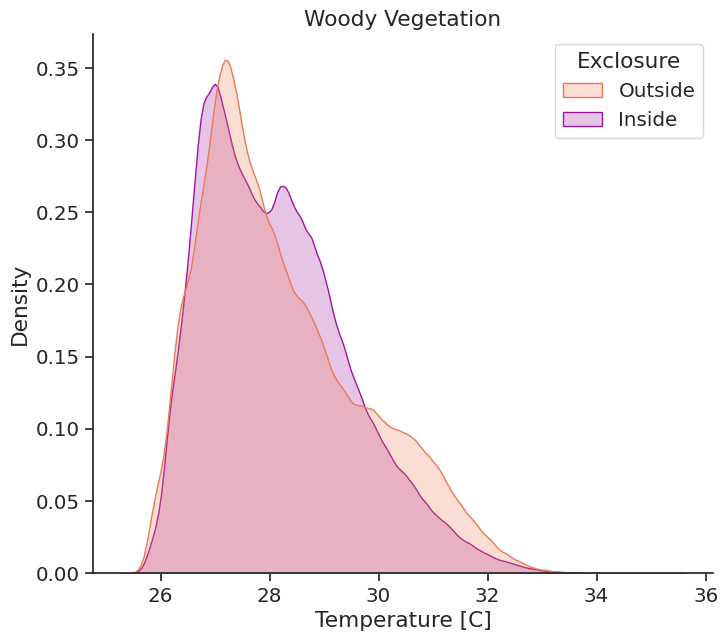

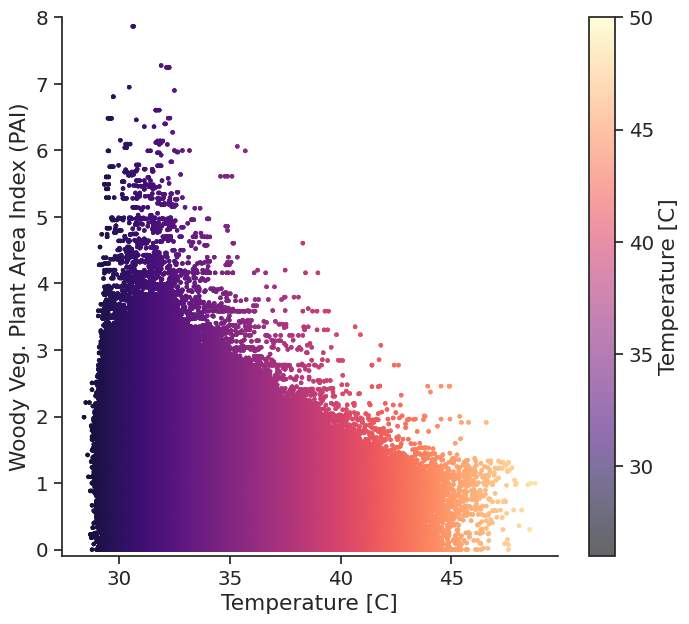

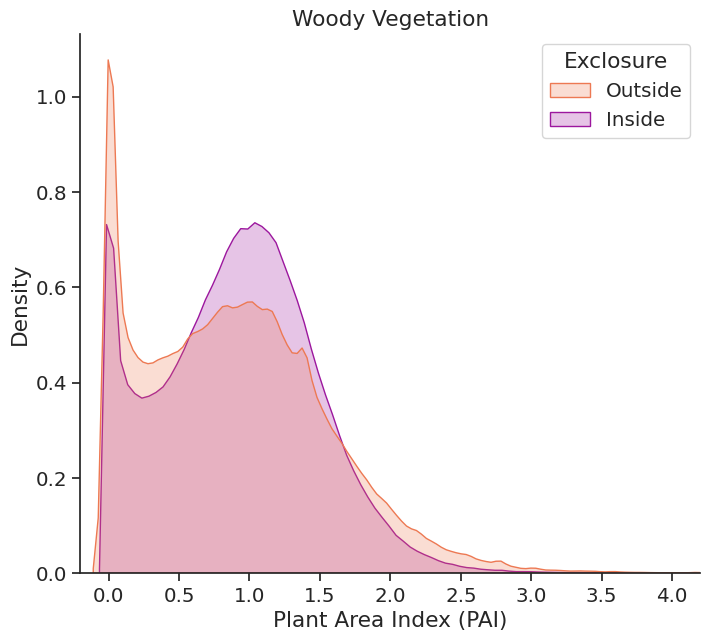

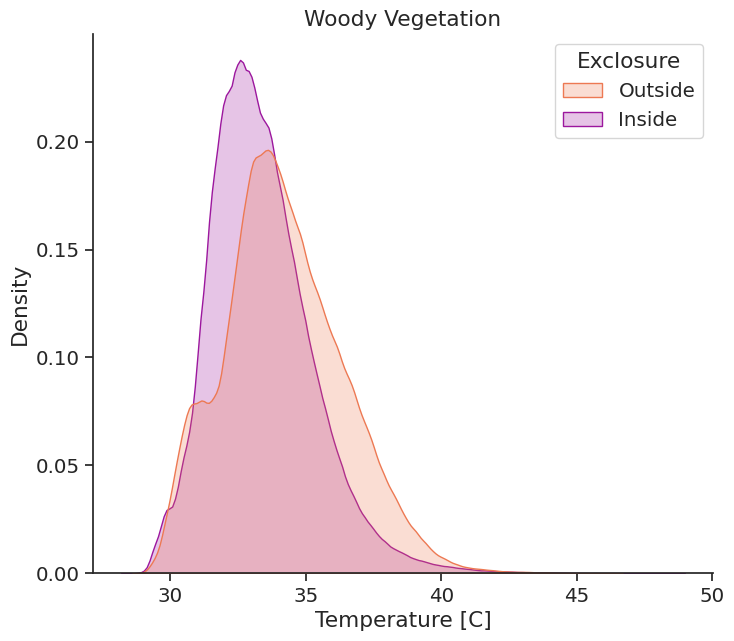

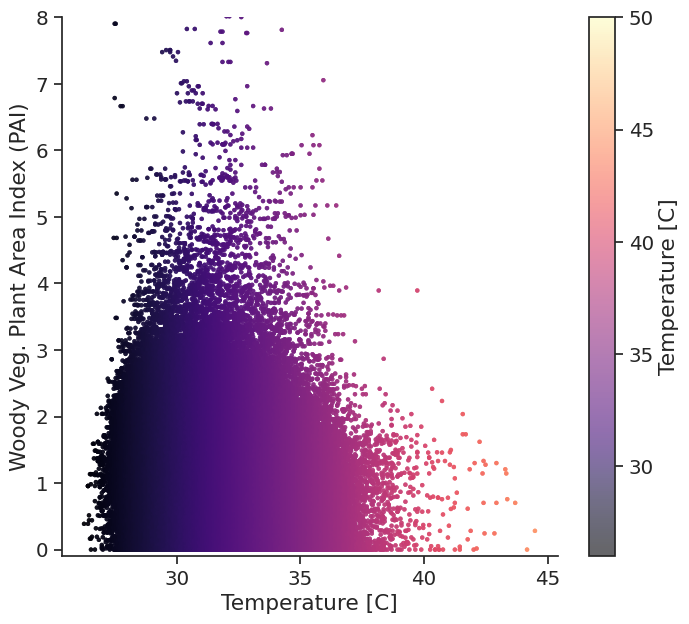

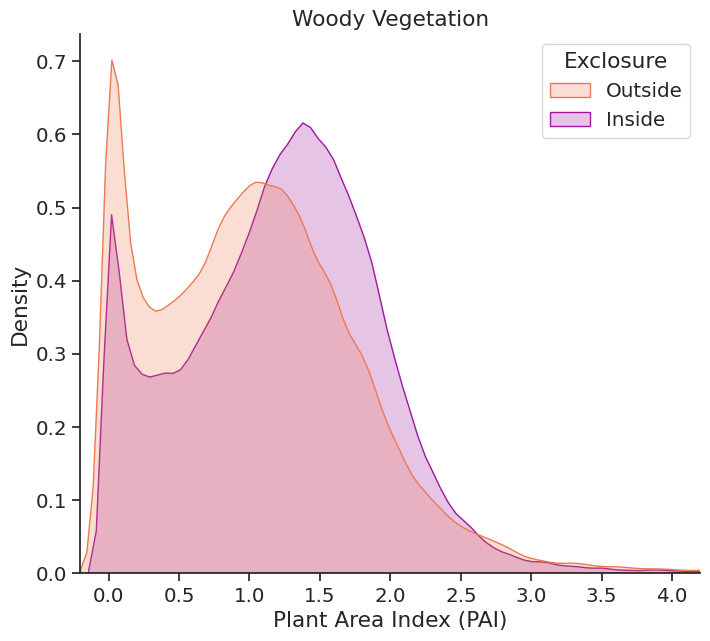

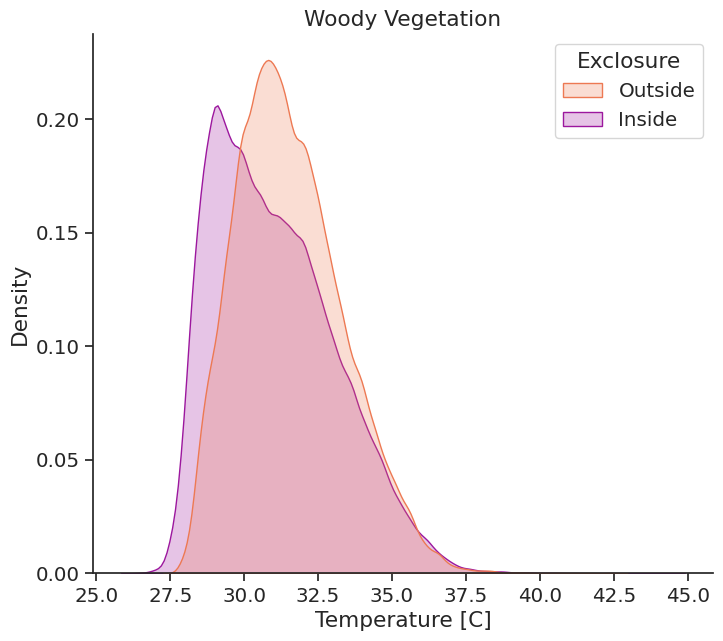

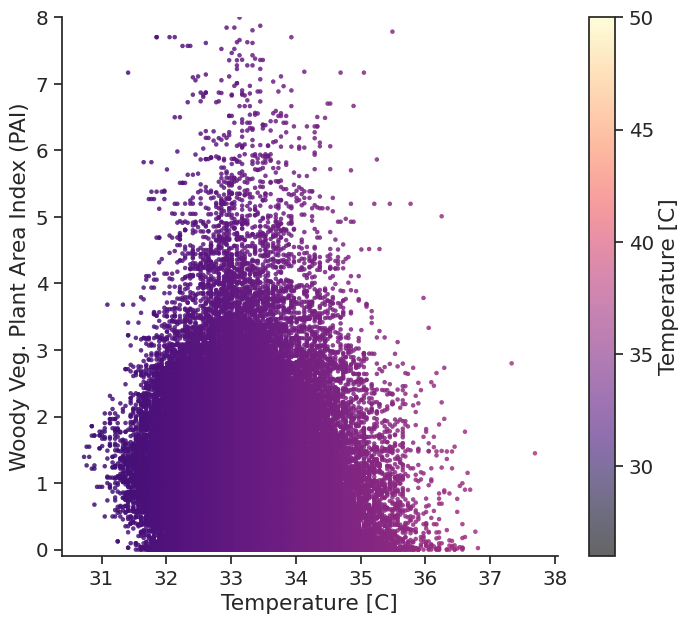

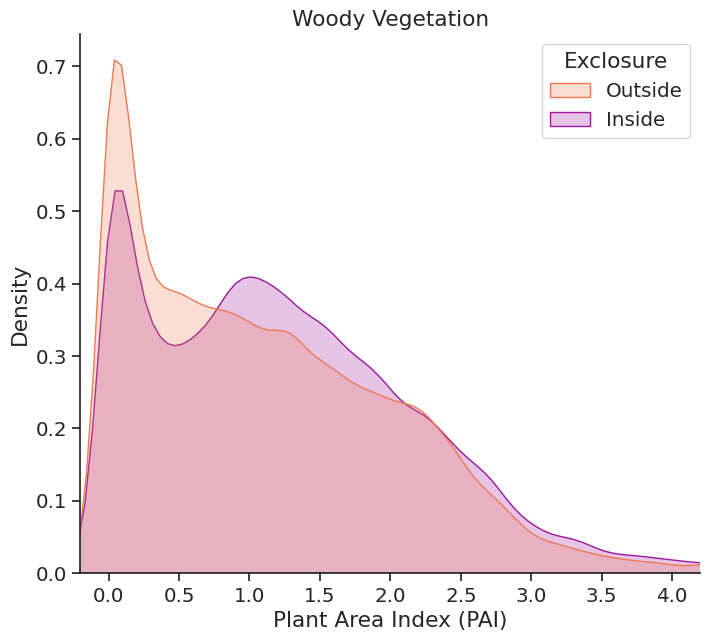

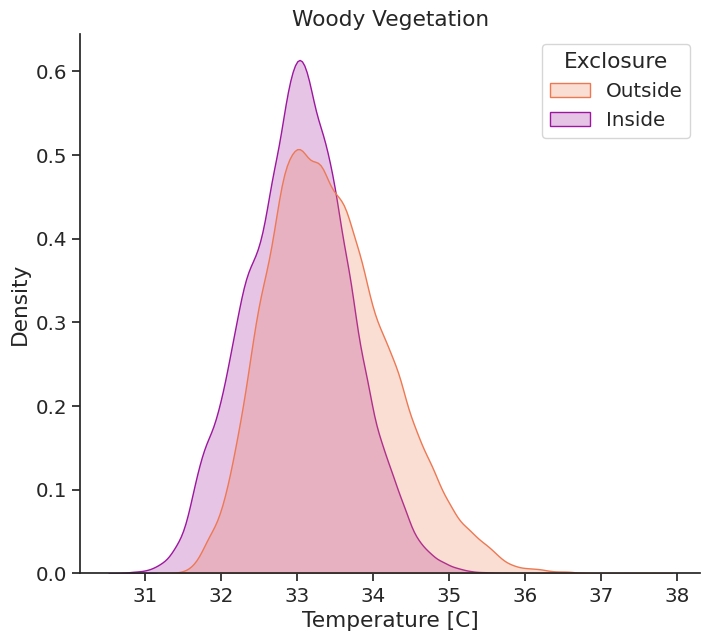

In [40]:
# Woody/Grass Figures
# Added late - 5/2/2023
# based on Nkuhlu code
# used in figure 3 - comparing tree and grass differences

plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 14})

# WOODY VEG - scatter plots and kde plots
for s in sites: 
    
    # # # Scatter plots - Temp x PAI
    # Subset by site
    df = pix_dict[s]
    
    # make a woody veg dataframe to plot
    df_veg = df.loc[(df.Height > 1)]

    # # # Make woody veg temp and pai scatter plots
    fig, ax = plt.subplots()
    

    # Plot Pai and temp scattered
    a = ax.scatter(x=df_veg.Temperature_eVeg,
                   y=df_veg.PAI,
                   c=df_veg.Temperature_eVeg,
                   alpha=0.6,
                   cmap='magma',
                   s=10,
                   marker='o',
                   edgecolors='none',
                   vmin=26,
                   vmax=50)

    fig.colorbar(a, label='Temperature [C]')

    ax.set_ylim(-0.1, 8)
    # ax.set_xlim(33, 55)

    ax.set_xlabel('Temperature [C]')
    ax.set_ylabel(f'Woody Veg. Plant Area Index (PAI)')

    fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_WoodyVeg_{s}.png', dpi=300)
    
    # KDE plot fo pai
    fig, ax = plt.subplots()

    sns.kdeplot(data=df_veg,
                x='PAI',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                common_norm=False)

    ax.set_xlim(-0.2, 4.2)
    ax.set_xlabel('Plant Area Index (PAI)')
    ax.set_title(f'Woody Vegetation')

    fig.savefig(f'{figdir}/KDEplot_PAIbyExclosure_WoodyVeg_{s}.png', dpi=300)
    
    
        # KDE plot of temp
    fig, ax = plt.subplots()

    sns.kdeplot(data=df_veg,
                x='Temperature_eVeg',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                common_norm=False)

    # ax.set_xlim(-0.2, 4.2)
    ax.set_xlabel('Temperature [C]')
    ax.set_title(f'Woody Vegetation')

    fig.savefig(f'{figdir}/KDEplot_TempbyExclosure_WoodyVeg_{s}.png', dpi=300)
    

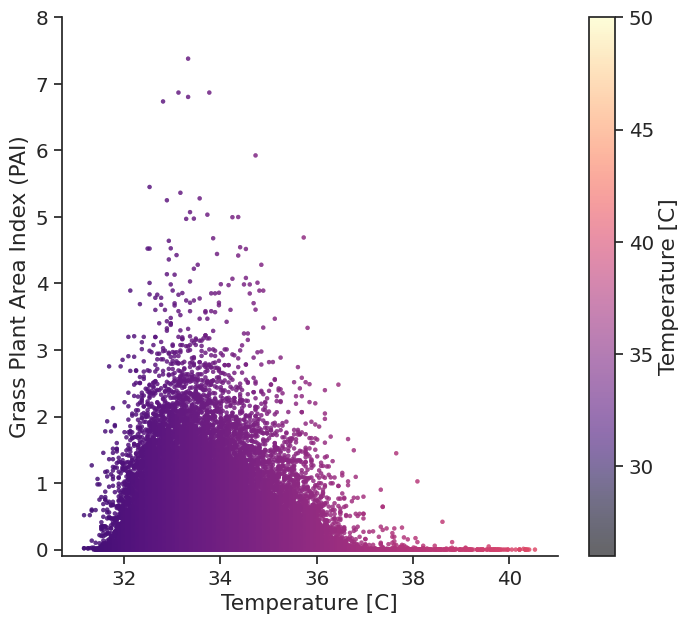

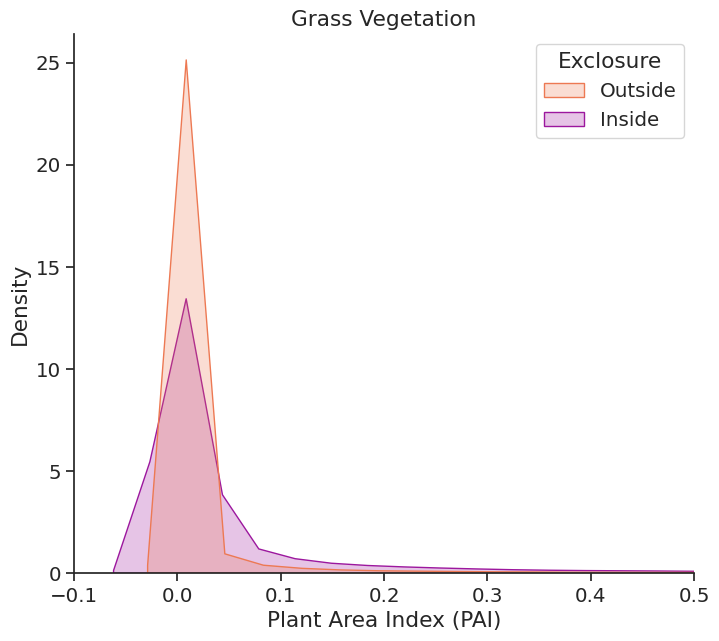

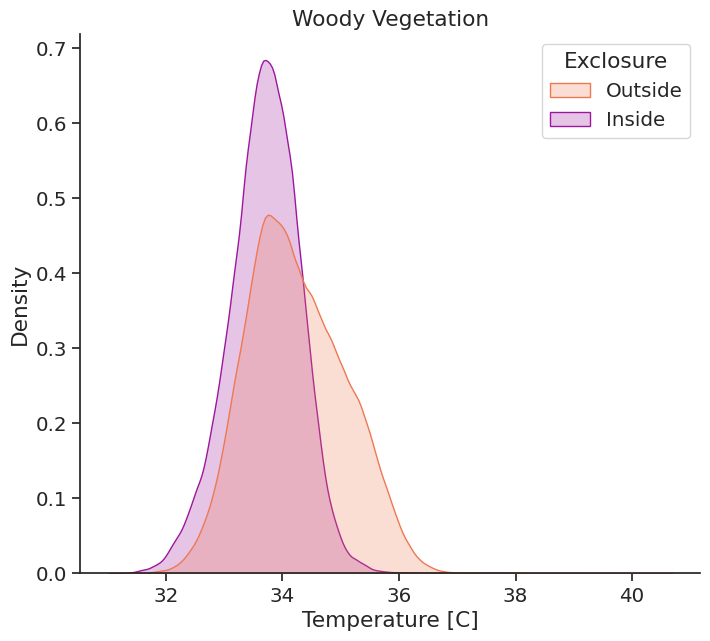

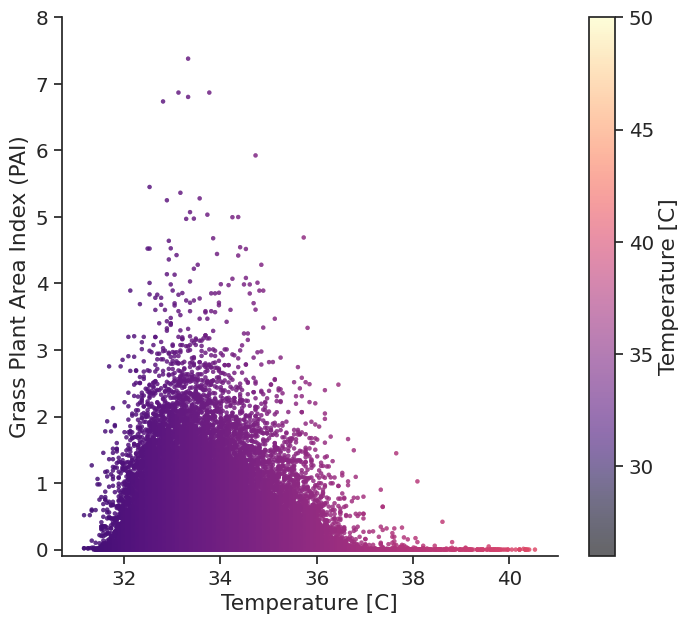

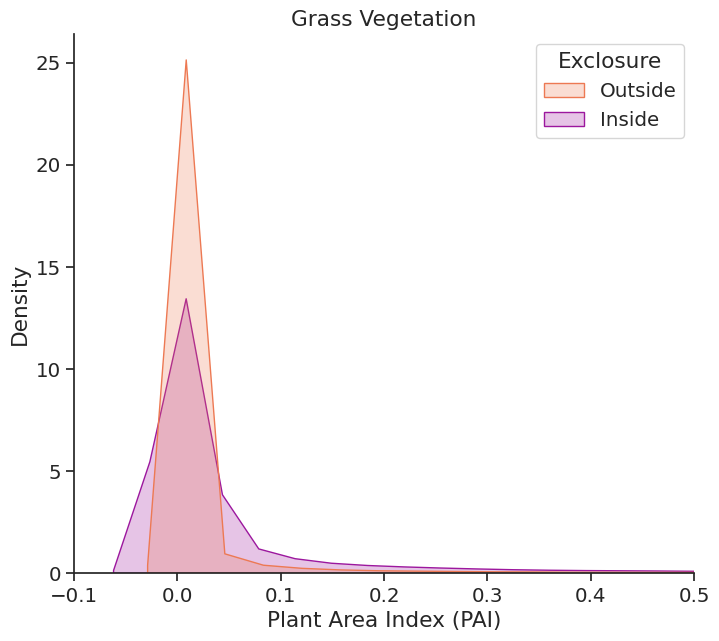

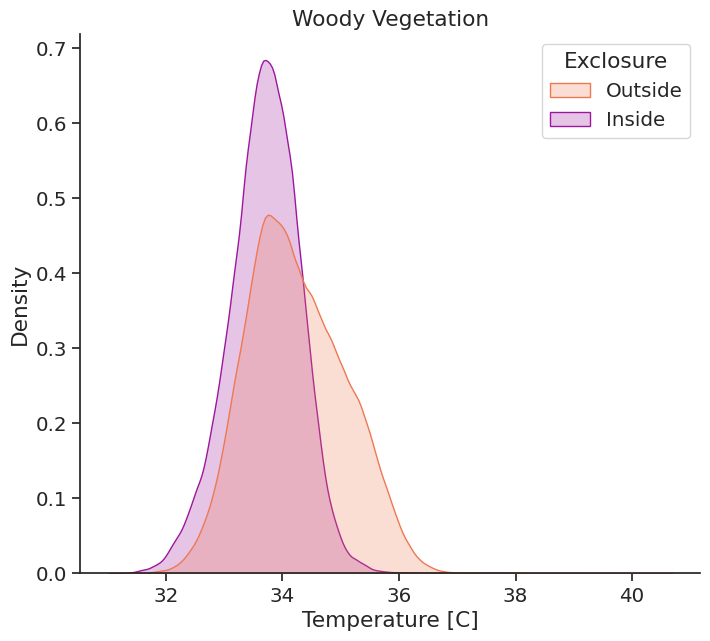

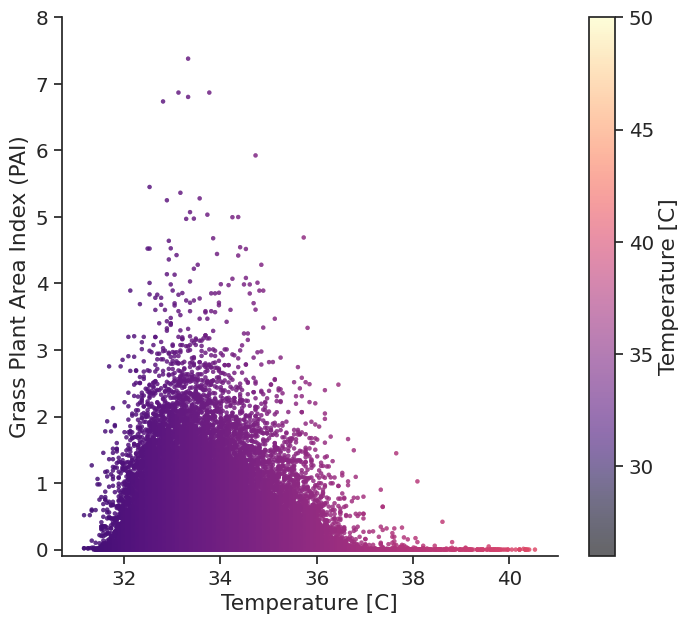

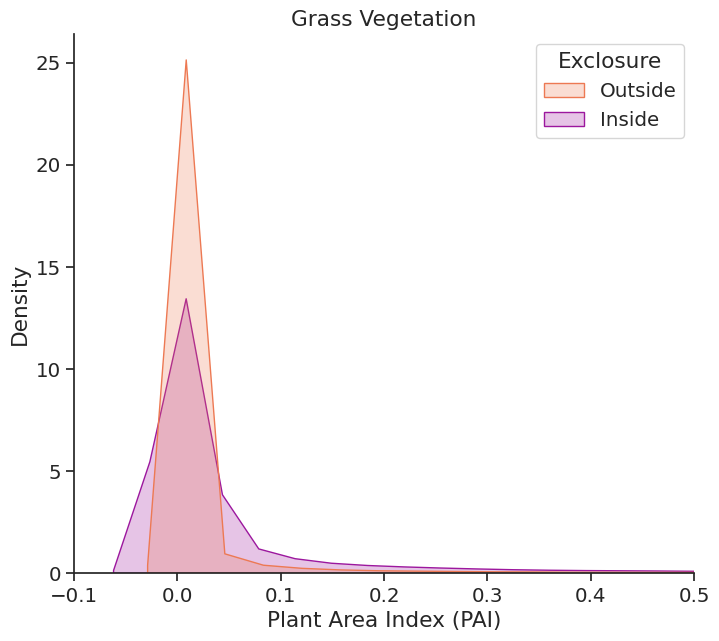

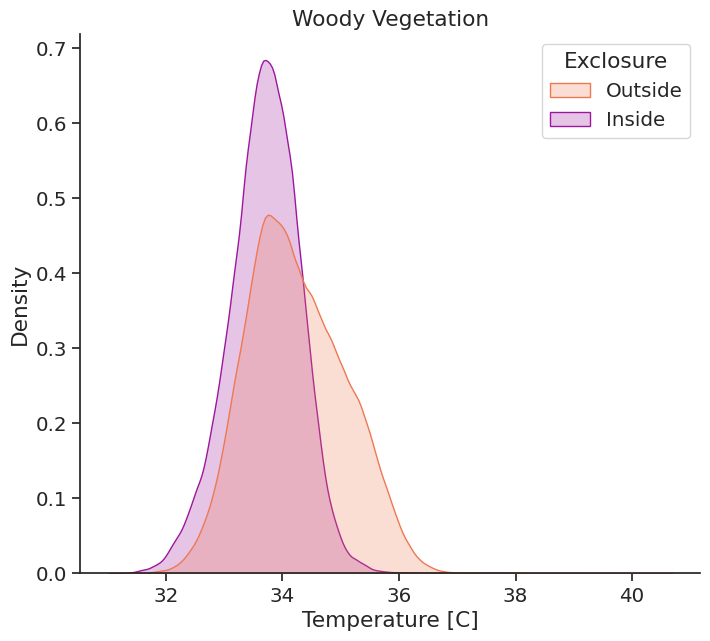

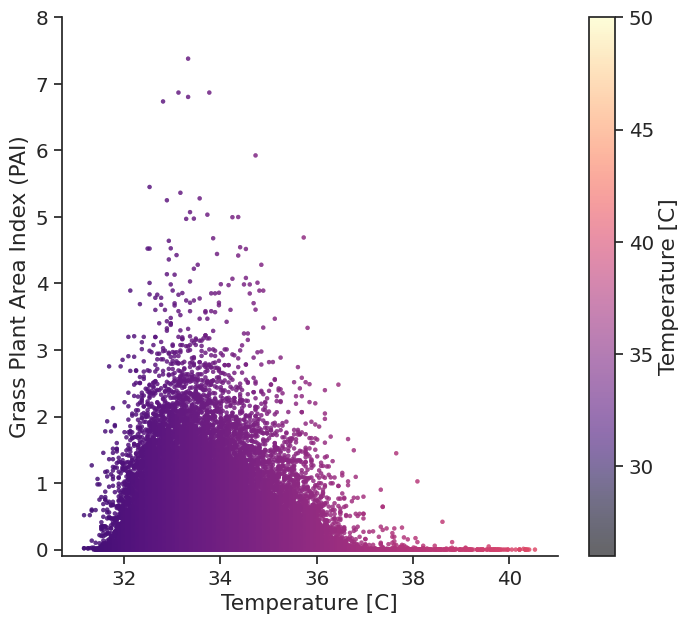

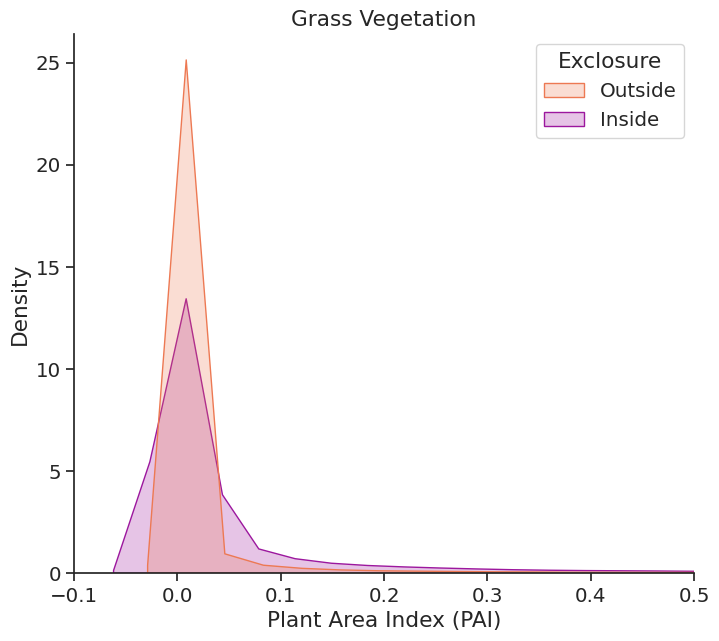

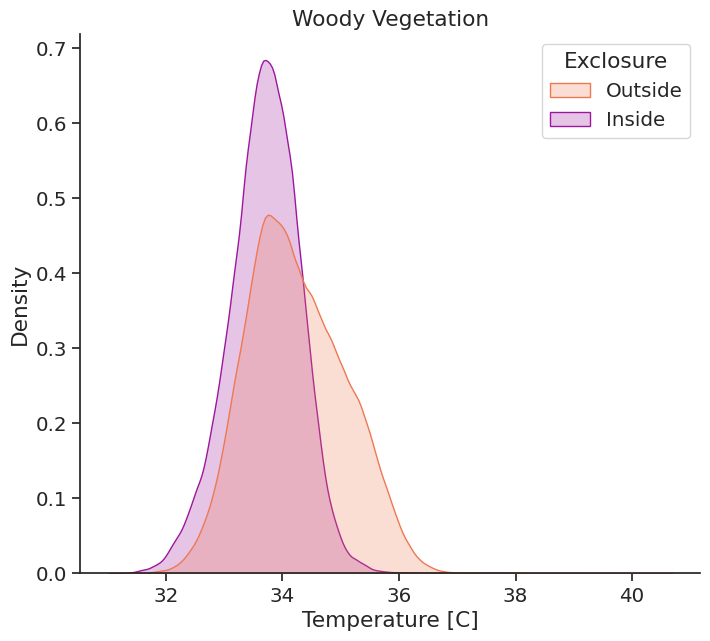

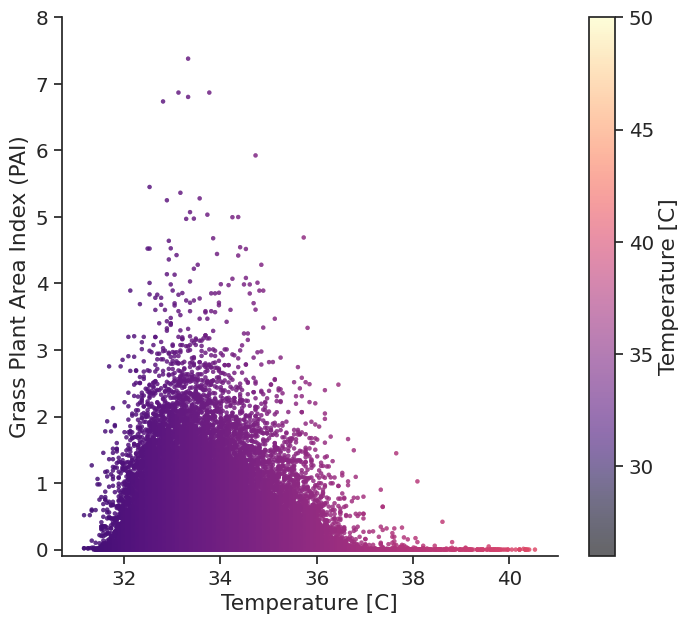

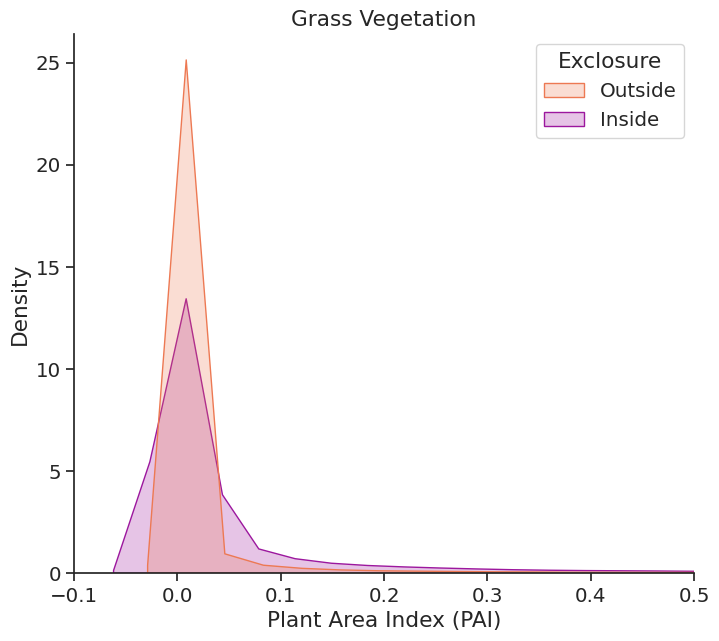

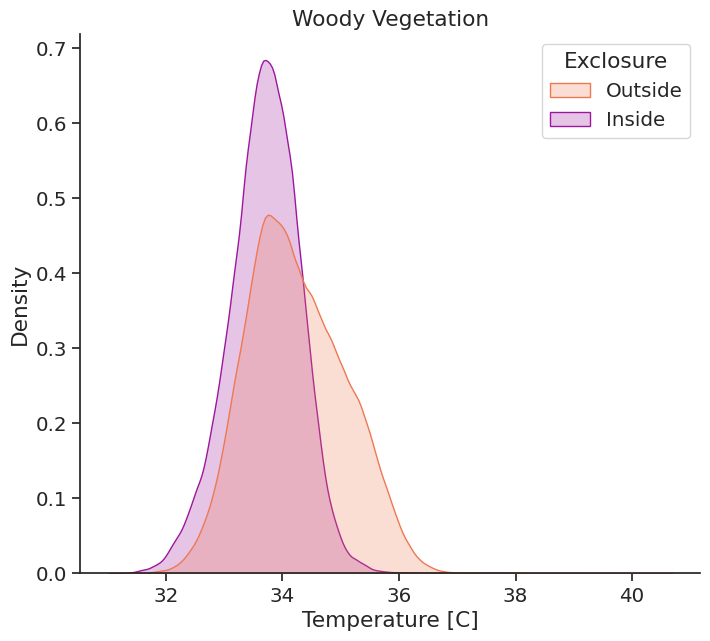

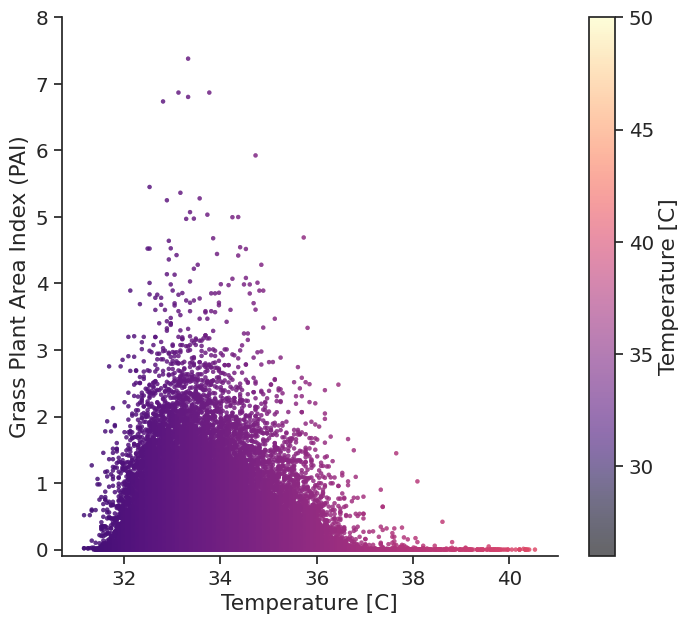

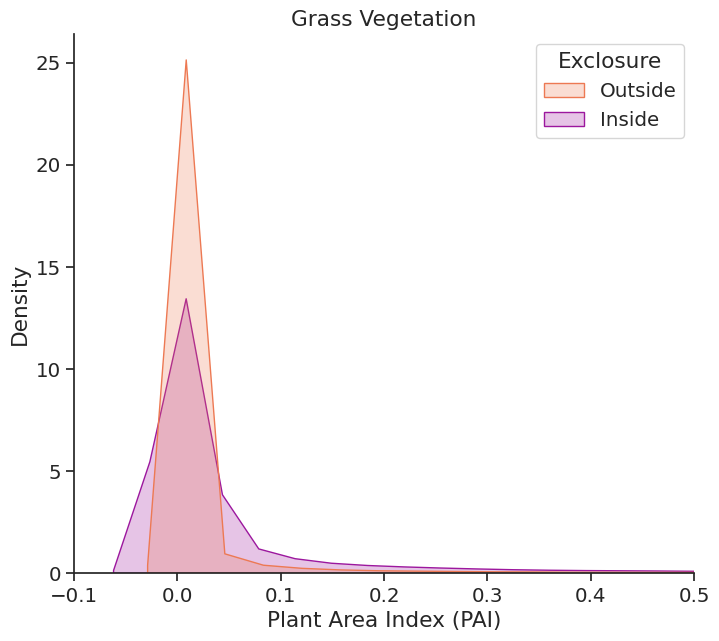

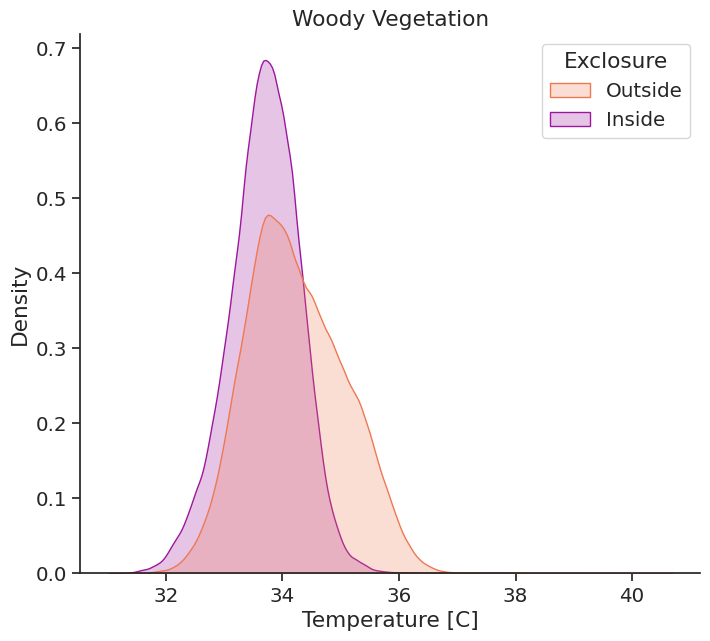

In [41]:
# Woody/Grass Figures
# Added late - 5/2/2023

# Grass - scatter plots and kde plots
for s in sites: 
    
    # # # Also make grass scatter plot
    
    fig, ax = plt.subplots()
    
    df_veg = df.loc[df.VegType == 'grass']
    
    a = ax.scatter(x=df_veg.Temperature_eVeg,
                   y=df_veg.PAI,
                   c=df_veg.Temperature_eVeg,
                   alpha=0.6,
                   cmap='magma',
                   s=10,
                   marker='o',
                   edgecolors='none',
                   vmin=26,
                   vmax=50)

    fig.colorbar(a, label='Temperature [C]')
    
    ax.set_ylim(-0.1, 8)

    # ax.set_xlim(33, 55)
    ax.set_xlabel('Temperature [C]')
    ax.set_ylabel(f'Grass Plant Area Index (PAI)')
    
    fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_Grass_{s}.png', dpi=300)
    
    # # Same thing, but for grass
    fig, ax = plt.subplots()

    sns.kdeplot(data=df_veg,
                x=f'PAI',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                common_norm=False)

    ax.set_xlim(-0.1, 0.5)
    ax.set_xlabel('Plant Area Index (PAI)')
    ax.set_title(f'Grass Vegetation')

    fig.savefig(f'{figdir}/KDEplot_PAIbyExclosure_Grass_{s}.png', dpi=300)
    
    
          # KDE plot of temp
    fig, ax = plt.subplots()

    sns.kdeplot(data=df_veg,
                x='Temperature_eVeg',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                common_norm=False)

    # ax.set_xlim(-0.2, 4.2)
    ax.set_xlabel('Temperature [C]')
    ax.set_title(f'Woody Vegetation')

    fig.savefig(f'{figdir}/KDEplot_TempbyExclosure_Grass_{s}.png', dpi=300)
    

In [42]:
figdir

PosixPath('/n/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes/src/3_process_figs_stats/figs/Final_6252026_WeatherUpdate')

### Scratch/Testing Below

In [ ]:
# Scratch for stats functions
# def ttest_by_Exclosure(df, var='Temperature'):
    
#     # Split by Inside and Outside
#     df_in = df.loc[df.Exclosure=='Inside']
#     df_out = df.loc[df.Exclosure=='Outside']
    
#     # Sample 66% of each DF for spatial autocorrelation
#     df_in = df_in.sample(frac=0.66)
#     df_out = df_out.sample(frac=0.66)
    
#     # Run a welch's t-test (equal variances not assumed)
#     t, p = ttest_ind(df_in[var],
#                      df_out[var],
#                      equal_var=False)
    
#     return p

# def CohensD_by_Exclosure(df, var='Temperature'):
    
#     # Split by Inside and Outside
#     df_in = df.loc[df.Exclosure=='Inside']
#     df_out = df.loc[df.Exclosure=='Outside']
    
#     # Sample 66% of each DF for spatial autocorrelation
#     df_in = df_in.sample(frac=0.66)
#     df_out = df_out.sample(frac=0.66)
    
#     # Return Cohen's D
#     cd = cohen_d(df_in[var],
#                  df_out[var])
    
#     return cd

# TTestbyImg_Temp = statsbyImg.apply(lambda x: ttest_by_Exclosure(x, var='Temperature'))
# CohensDbyImg_Temp = statsbyImg.apply(lambda x: CohensD_by_Exclosure(x, var='Temperature'))